# TECH CHALLENGE FASE 1

**Base de dados escolhida:** PCOS_DataSet - base de dados com 684 amostras de mulheres com e sem o diagnósico de Síndrome do Ovário Policístico (SOP).

## Etapa 1: Análise Exploratória dos Dados (EDA)

In [543]:
#Primeiro passo: importação das bibliotecas que eu vou usar:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import missingno as msno

In [544]:
#Instalação para o pandas conseguir abrir e ler meu arquivo de excel:
!conda install openpyxl -y

Jupyter detected...
2 channel Terms of Service accepted
Channels:
 - defaults
Platform: osx-arm64
Solving environment: done


==> WARNING: A newer version of conda exists. <==
    current version: 26.1.1
    latest version: 26.7.1

Please update conda by running

    $ conda update -n base -c defaults conda



# All requested packages already installed.



In [545]:
#Agora vamos importar a base de dados e, na sequência, usar o método .head() do pandas para ter um primeiro contato com a nossa
#base de dados (quantas colunas, seus nomes, tipos de dados e etc):

dataset = pd.read_excel('../dataset/PCOS_DataSet.xlsx')

dataset.head()

,PCOS,Family_background,LH_hormone,FSH_hormone,Diabetes_measurment,TSH_hormone,Prolactin_hormone,Hemoglobin_level,Cyst_ovary,Diagnosis_age,Overweight,Period_type,Hormonal_imbalance,Gain_weight,Excess_facial_hair,Excess_body_hair,Dark_area,Pimple_face,Hormonal_acne_face,Blood_pressure,Fast_food,Losing_hair,Ex_pain_abdominal,Mood_swing_period,Mood_swing_normal,Craving_PT,Depress,Mental_stress,Insomnia,Slow_activity,Weight(kg),Height(m),BMI(kg/m*m)
0,1,Yes,Normal,Abnormal,Abnormal,Abnormal,Normal,Normal,Yes,Youth,Yes,Irregular,Yes,Yes,Yes,Yes,No,Yes,Yes,Normal,Yes,Yes,Yes,High,High,High,Yes,Yes,No,Yes,60.0,1.5494,25.0
1,1,I do not know,I do not know,I do not know,I do not know,I do not know,I do not know,I do not know,i do not know,adult,No,Regular,Yes,May be,Yes,Yes,Yes,Yes,Yes,High,Yes,Yes,No,High,High,High,No,No,Yes,Yes,34.0,1.5494,14.2
2,0,I do not know,I do not know,I do not know,I do not know,I do not know,I do not know,I do not know,i do not know,adult,No,Regular,No,No,No,Yes,Yes,No,No,Low,Yes,No,Yes,High,Medium,High,Yes,Yes,Yes,Yes,60.0,1.6510,22.0
3,1,No,Normal,Normal,Normal,Normal,Normal,Normal,No,Youth,No,Irregular,No,Yes,Yes,No,Yes,Yes,Yes,Low,Yes,Yes,Yes,Extreme,Medium,Medium,Yes,Yes,No,Yes,65.0,1.7018,22.4
4,0,I do not know,I do not know,I do not know,I do not know,I do not know,I do not know,I do not know,i do not know,adult,No,Regular,No,No,No,No,No,No,No,Normal,No,Yes,No,Normal,Normal,Normal,No,No,No,No,47.0,1.5240,20.2


In [546]:
#Método .shape para saber o número exato de colunas e de amostras da nossa base de dados:

dataset.shape

(684, 33)

**Primeiro insight:** há poucas amostras, o que me faz considerar usar o método de validação cruzada para que todas elas possam ser usadas tanto para treino quanto para teste. O número de coluna não é enorme, mas é considerável. Se eu for aplicar um KNN, talvez seja bom aplicar antes o PCA para reduzir a minha dimensionalidade e consequentemente o tamanho do meu espaço multidimensional.

In [547]:
#Com o método .info(), eu consigo ver o tipo de dado de cada coluna, bem como a contagem de amostras não nulas para cada uma delas:

dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 684 entries, 0 to 683
Data columns (total 33 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   PCOS                 684 non-null    int64  
 1   Family_background    684 non-null    object 
 2   LH_hormone           684 non-null    object 
 3   FSH_hormone          684 non-null    object 
 4   Diabetes_measurment  684 non-null    object 
 5   TSH_hormone          684 non-null    object 
 6   Prolactin_hormone    684 non-null    object 
 7   Hemoglobin_level     684 non-null    object 
 8   Cyst_ovary           684 non-null    object 
 9   Diagnosis_age        684 non-null    object 
 10  Overweight           684 non-null    object 
 11  Period_type          684 non-null    object 
 12  Hormonal_imbalance   684 non-null    object 
 13  Gain_weight          684 non-null    object 
 14  Excess_facial_hair   684 non-null    object 
 15  Excess_body_hair     684 non-null    obj

In [548]:
#Aparentemente, não há dados nulos na base de dados, mas vou usar o método .isnull() para me certificar:

dataset.isnull().sum()

PCOS                   0
Family_background      0
LH_hormone             0
FSH_hormone            0
Diabetes_measurment    0
TSH_hormone            0
Prolactin_hormone      0
Hemoglobin_level       0
Cyst_ovary             0
Diagnosis_age          0
Overweight             0
Period_type            0
Hormonal_imbalance     0
Gain_weight            0
Excess_facial_hair     0
Excess_body_hair       0
 Dark_area             0
Pimple_face            0
Hormonal_acne_face     0
Blood_pressure         0
Fast_food              0
Losing_hair            0
 Ex_pain_abdominal     0
Mood_swing_period      0
 Mood_swing_normal     0
 Craving_PT            0
Depress                0
Mental_stress          0
Insomnia               0
Slow_activity          0
Weight(kg)             0
Height(m)              0
BMI(kg/m*m)            0
dtype: int64

**Insight:** embora não haja dados explicitamente nulos no dataset, a observação das primeiras amostras já nos mostrou que algumas células contêm a informação "I do not know", o que poderia ser considerado como dado nulo. Visando entender a magnitude desse problema, vou usar o método value_counts em todas as colunas para saber quais delas contêm esse tipo de informação e em qual quantidade.

In [549]:
categoric_columns = dataset.select_dtypes(exclude=['number']).columns

for col in categoric_columns:
  print(dataset[col].value_counts())
  print("")

Family_background
No               292
Yes              244
I do not know    148
Name: count, dtype: int64

LH_hormone
Normal           241
Abnormal         222
I do not know    221
Name: count, dtype: int64

FSH_hormone
Normal           274
I do not know    219
Abnormal         191
Name: count, dtype: int64

Diabetes_measurment
Normal           444
I do not know    179
Abnormal          61
Name: count, dtype: int64

TSH_hormone
Normal           376
I do not know    210
Abnormal          98
Name: count, dtype: int64

Prolactin_hormone
I do not know    252
Abnormal         217
Normal           215
Name: count, dtype: int64

Hemoglobin_level
Normal           372
I do not know    213
Abnormal          99
Name: count, dtype: int64

Cyst_ovary
Yes              350
i do not know    235
No                99
Name: count, dtype: int64

Diagnosis_age
Young adult    328
adult          199
Youth          157
Name: count, dtype: int64

Overweight
Yes    427
No     257
Name: count, dtype: int64

Per

**Insights:** Dados faltantes "disfarçados" com as respostas "I do not know"e sua versão "i do no know" estão presentes em 8 das 33 colunas, ou seja, em aproximadamente 25% das colunas. Além disso, há um número bastante expressivo de amostras com esse tipo de informação em cada coluna que a contém. A coluna 'Hormonal_imbalance' também tem um dado que não representa nada (possível typo), que é o número 2 em uma coluna binária de 'Yes' ou 'No'.

Isso nos mostra que tratar esses dados de maneira simples, usando o SimpleImputer, por exemplo, provavelmente enviesaria muito os dados; da mesma forma, como o volume de amostras com dados ausentes é alto, eliminar essas amostras também não funcionaria.
Dessa forma, vou optar por mantê-los como uma terceira categoria mesmo, indicando pacientes para as quais não foram solicitados exames médicos (todas as colunas com dados faltantes, com exceção da coluna de histórico familiar, são colunas com dados de níveis hormonais, resultantes de exames).

In [550]:
#Ainda visando conhecer um pouco mais sobre como estão distribuídos esses dados faltantes, vou criar uma cópia do meu dataset,
#substituindo os dados "I do not know", "i do not know"  e "2" por NaN, para poder usar a biblioteca missingno para entender melhor esses dados.

dataset_copy = dataset.replace({'I do not know': np.nan, 'i do not know': np.nan})
dataset_copy['Hormonal_imbalance'] = dataset_copy['Hormonal_imbalance'].replace(2, np.nan)

<Axes: >

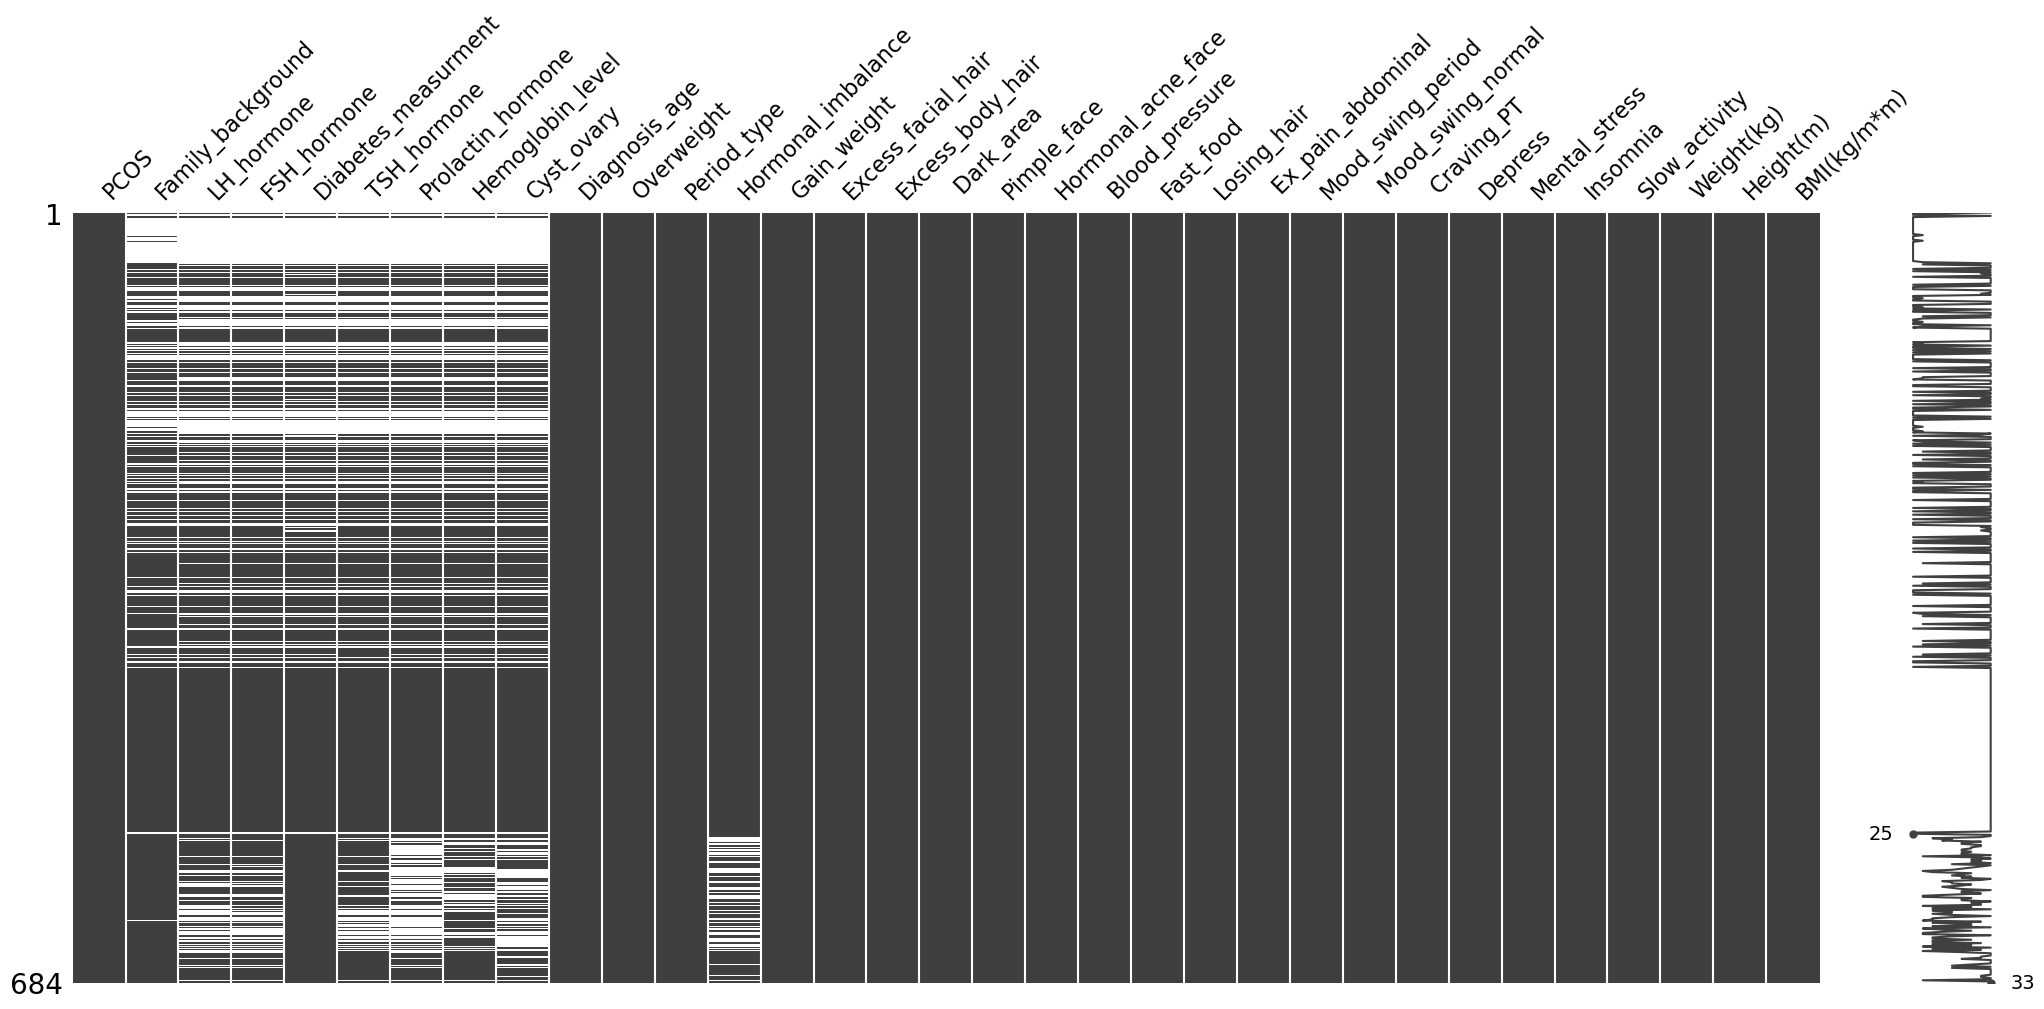

In [551]:
#Vou iniciar usando o método .matrix() da biblioteca missingno, porque sua visualização é muito boa para nos mostrar se os dados ausentes
#estão concentrados sempre nas mesmas amostras para as diferentes colunas ou se eles estão mais distribuídos em amostras diferentes.

msno.matrix(dataset_copy)

<Axes: >

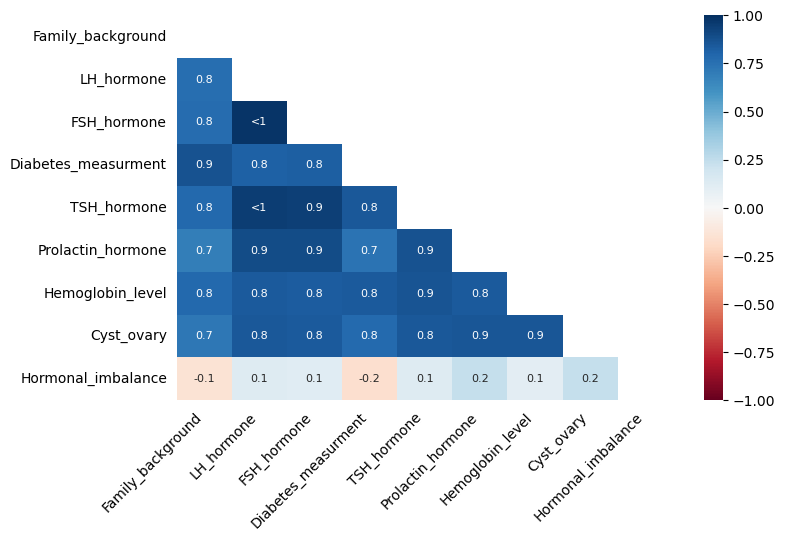

In [552]:
msno.heatmap(dataset_copy, figsize=(8,5), fontsize=10)

**Insights:** as análises feitas com os métodos .matrix() e .heatmap() da biblioteca missingno nos mostra que os dados ausentes nas colunas costumam andar juntos, isto é, quando uma das colunas não tem o dado, provavelmente as outras 7 também não terão. É isso que nos indica essas grandes faixas brancas nas colunas 2 a 9 na matriz gerada pelo método .matrix(). Já a coluna 'Hormonal_imbalance' tem sua concentração de dados ausentes somente na parte final das amostras e nem sempre acompanha as amostras com dados ausentes das demais 8 colunas.

Já o heatmap nos confirma a forte correlação entre as 8 colunas de níveis hormonais + cisto no ovário e a baixa correlação entre essas colunas e a coluna de 'Hormonal_imbalance'. Entre as colunas dos níveis hormonais, a correlação está sempre acima de 0.7, indicando que, quando um dado está presente em uma das colunas, ele provavelmente está também presente nas demais. O destaque vai para as colunas FSH_hormone, TSH_hormone e LH_hormone, cujos dados ausentes parecem andar muito junto, provavelmente indicando que são exames pedidos juntos pelos médicos.

In [585]:
#Vou aproveitar para ver se existe uma predominância dos dados nulos entre as pacientes não diagnosticadas com SOP, ou se as
#pacientes diagnosticadas também apresentam ausência de exames:

missing_data_cols = list(dataset_copy.loc[:, dataset_copy.isnull().any()])

for col in missing_data_cols:
  print(col)
  print(dataset_copy[col].isnull().groupby(dataset_copy['PCOS']).sum())
  print("")
  print("=================================")
  print("")

Family_background
PCOS
0    89
1    59
Name: Family_background, dtype: int64


LH_hormone
PCOS
0    120
1    101
Name: LH_hormone, dtype: int64


FSH_hormone
PCOS
0    117
1    102
Name: FSH_hormone, dtype: int64


Diabetes_measurment
PCOS
0    88
1    91
Name: Diabetes_measurment, dtype: int64


TSH_hormone
PCOS
0    117
1     93
Name: TSH_hormone, dtype: int64


Prolactin_hormone
PCOS
0    141
1    111
Name: Prolactin_hormone, dtype: int64


Hemoglobin_level
PCOS
0    121
1     92
Name: Hemoglobin_level, dtype: int64


Cyst_ovary
PCOS
0    130
1    105
Name: Cyst_ovary, dtype: int64


Hormonal_imbalance
PCOS
0    41
1     9
Name: Hormonal_imbalance, dtype: int64




**Insights:** não existe uma predominância clara de dados faltantes na categoria de mulheres diagnosticadas com a SOP ou não diagnosticadas. Pelo menos, não em valores absolutos.

In [554]:
#Vamos dar uma olhada na proporção da variável-target (PCOS) no dataset:

dataset.PCOS.value_counts()

PCOS
1    521
0    163
Name: count, dtype: int64

In [555]:
#Usando os valores acima, podemos encontrar a proporção de dados ausentes em relação ao total da categoria:

for col in missing_data_cols:
  percent = dataset_copy[col].isnull().groupby(dataset_copy['PCOS']).mean()*100
  print(col)
  print(percent.round(2))
  print("")
  print("=================================")
  print("")

Family_background
PCOS
0    54.60
1    11.32
Name: Family_background, dtype: float64


LH_hormone
PCOS
0    73.62
1    19.39
Name: LH_hormone, dtype: float64


FSH_hormone
PCOS
0    71.78
1    19.58
Name: FSH_hormone, dtype: float64


Diabetes_measurment
PCOS
0    53.99
1    17.47
Name: Diabetes_measurment, dtype: float64


TSH_hormone
PCOS
0    71.78
1    17.85
Name: TSH_hormone, dtype: float64


Prolactin_hormone
PCOS
0    86.50
1    21.31
Name: Prolactin_hormone, dtype: float64


Hemoglobin_level
PCOS
0    74.23
1    17.66
Name: Hemoglobin_level, dtype: float64


Cyst_ovary
PCOS
0    79.75
1    20.15
Name: Cyst_ovary, dtype: float64


Hormonal_imbalance
PCOS
0    25.15
1     1.73
Name: Hormonal_imbalance, dtype: float64




**Insights:** esta nova perspectiva, nos mostrou que a ausência de dados é predominante entre as mulheres não diagnosicadas com SOP; esta informação se perde quando em números absolutos porque o dataset está **muito desbalanceado** com forte predominância de mulheres diagnosticadas com SOP - 76,2% contra somente 23,8% não diagnosticadas.

In [586]:
dataset = dataset.replace({'I do not know': 'Missing', 'i do not know': 'Missing'})
dataset['Hormonal_imbalance'] = dataset['Hormonal_imbalance'].replace(2, 'Missing')

In [556]:
#Por fim, quero dar uma olhada nos dados numéricos antes de começar a plotar os gráficos. 
#No momento, me interessa somente ver os valores de média e mediana para as 3 colunas numéricas agrupadas pela coluna
#da variável-target para ver se há uma diferença entre as mulheres diagnosticadas com SOP e as não diagnosticadas

numeric_cols = dataset.select_dtypes(include=["number"])
numeric_cols = numeric_cols.drop('PCOS', axis=1).columns

print("MEAN:")
print(dataset.groupby('PCOS')[numeric_cols].mean())
print("")
print("=========================================")
print("")
print("MEDIAN:")
print(dataset.groupby('PCOS')[numeric_cols].median())

MEAN:
      Weight(kg)  Height(m)  BMI(kg/m*m)
PCOS                                    
0      56.079755   1.585316    21.910429
1      68.174088   1.574525    27.067370


MEDIAN:
      Weight(kg)  Height(m)  BMI(kg/m*m)
PCOS                                    
0           54.0     1.6002         21.5
1           67.0     1.5748         27.0


**Insights:** a proximidade dos valores das medianas dos valores das respectivas médias indica que essas colunas não devem ter muitos outliers porque eles não puxaram a média nem muito para cima e nem muito para baixo em relação aos respectivos valores de medianas para nenhuma das 3 categorias.

Enquanto não há diferença significativa entre a altura de mulheres com e sem o diagnóstico de SOP, as categorias de peso e IMC indicam que mulheres com SOP têm maior acúmulo de gordura (IMC elevado).

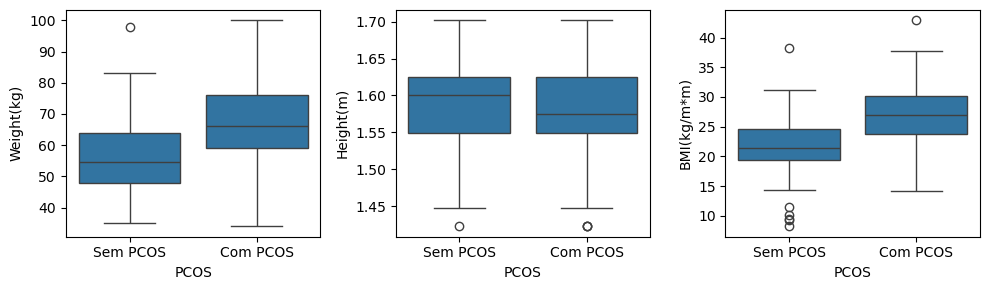

In [587]:
#Vamos seguir com a análise dos dados contínuos com um boxplot para ver as principais métricas de forma mais gráfica.
#O boxplot também nos ajudará a confirmar a ideia de que mulheres diagnosticadas com SOP têm mais problema de sobrepeso
#(IMC elevado) do que as mulheres sem o diagnóstico.

fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(10, 3))

for index in range(len(numeric_cols)):
  sns.boxplot(x='PCOS', y=numeric_cols[index], data=dataset, ax=axes[index])
  axes[index].set_xticks(ticks=[0,1], labels=['Sem PCOS', 'Com PCOS'])

plt.tight_layout()

**Insights:** os gráficos me comprovaram o que a média e mediana desses dados já tinham sugerido: peso e IMC têm os valores médios e máximos mais altos para mulheres com SOP. Nas mulheres diagnosticadas, há maior presença de outliers para cima da média de peso e IMC.

Mas, além disso, o boxplot me trouxe outras informações que eu ainda não tinha: pelo gráfico da variável de altura, foi possível ver existe um ou mais dados nulos nesta coluna (Height(m)), que eu deveria excluir ou tratar para visualizar melhor o boxplot dessa variável; da mesma forma, na coluna de IMC (BMI(kg/m*m)), há também dados nulos.

In [588]:
#Vamos confirmar se este outlier da coluna Height(m) é de fato um valor nulo e, na sequência, caso seja, vamos ver se 
#existe apenas um, ou se há mais de um escondidos pela sobreposição dos marcadores:

min_height_value = dataset['Height(m)'].min()
print(f"O valor mínimo de altura é: {min_height_value}.")
print(f"Existem {(dataset['Height(m)'] == min_height_value ).sum()} valores {min_height_value} na coluna de altura do dataset.")

O valor mínimo de altura é: 1.4224.
Existem 4 valores 1.4224 na coluna de altura do dataset.


In [589]:
#Vamos fazer o mesmo para a coluna do IMC:

min_bmi_value = dataset['BMI(kg/m*m)'].min()
print(f"O valor mínimo do IMC é: {min_bmi_value}.")
print(f"Existem {(dataset['BMI(kg/m*m)'] == min_bmi_value ).sum()} valores {min_bmi_value} na coluna de altura do dataset.")

O valor mínimo do IMC é: 8.2.
Existem 1 valores 8.2 na coluna de altura do dataset.


In [590]:
#Como o IMC depende da altura para ser calculado, podemos imaginar que as amostras com BMI = 0 sejam as mesmas 
#amostras cuja altura é igual a zero. Vamos confirmar isso:

dataset.loc[dataset['Height(m)'] == 0.0]

,PCOS,Family_background,LH_hormone,FSH_hormone,Diabetes_measurment,TSH_hormone,Prolactin_hormone,Hemoglobin_level,Cyst_ovary,Diagnosis_age,Overweight,Period_type,Hormonal_imbalance,Gain_weight,Excess_facial_hair,Excess_body_hair,Dark_area,Pimple_face,Hormonal_acne_face,Blood_pressure,Fast_food,Losing_hair,Ex_pain_abdominal,Mood_swing_period,Mood_swing_normal,Craving_PT,Depress,Mental_stress,Insomnia,Slow_activity,Weight(kg),Height(m),BMI(kg/m*m)


### <u>Tratamento dos dados nulos:<u>

Embora o tratamento dos dados nulos deva ser feito na etapa de pré-processamento dos dados, eu vou adiantá-lo para poder analisar melhor os dados nos gráficos. Minha ideia aqui é **padronizar** os dados **ausentes** nas colunas categóricas, substituindo os valores 'I do not know', 'i do not know' e 2 pelo padrão 'Missing'. Assim, evito substituir esses dados pelo valor da moda ou removê-los do dataset para evitar enviesar os dados ou diminuir muito minha quantidade de amostras. Esses dados ausentes serao amntidos como uma terceira categoria.

Por outro lado, a amostra nula na coluna da altura, por serem apenas duas amostras, eu vou tratar substituindo pelo valor da média, caso a distribuição dos dados dessa coluna seja normal, ou da mediana, caso não seja.

array([[<Axes: title={'center': 'Weight(kg)'}>,
        <Axes: title={'center': 'Height(m)'}>],
       [<Axes: title={'center': 'BMI(kg/m*m)'}>, <Axes: >]], dtype=object)

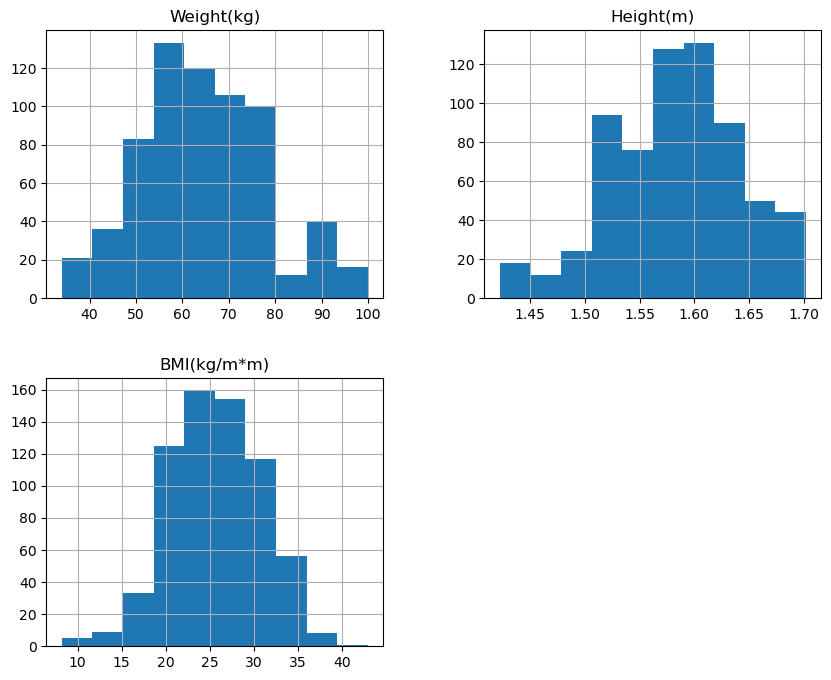

In [591]:
#Vamos então plotar a distribuição das minhas variáveis numéricas:

ds_copy = dataset.copy()

index_for_null_height = ds_copy[ds_copy['Height(m)'] == 0.0].index

ds_copy = ds_copy.drop(index=index_for_null_height)

ds_copy[numeric_cols].hist(figsize=(10,8))

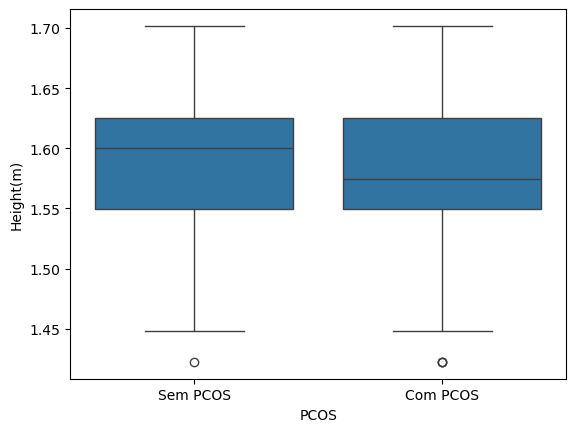

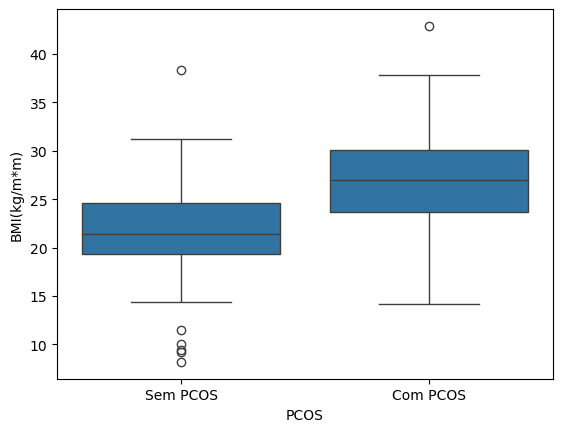

In [592]:
#Como deu para perceber pelo histograma, a cariável da altura (Height(m)) parece ter uma distribuição normal (Peso e IMC apresentam mais 
#outliers para a direita dos gráficos). Por ter uma distribuição normal, vou fazer a substituição dos valores nulos da coluna de altura 
#pelo valor da média das amostras.

#Primeiro, vamos encontrar o peso para as colunas em que a altura é igual a zero (isso vais er importante para a coluna de IMC):
weights_for_zero_height_line = dataset.loc[dataset['Height(m)'] == 0, 'Weight(kg)']
indexes_for_zero_height = weights_for_zero_height_line.index
weights_for_zero_height = weights_for_zero_height_line.values

dataset['Height(m)'] = dataset['Height(m)'].replace(0.0, dataset['Height(m)'].mean())

#Como a altura foi preenchida com o valor médio, podemos usá-lo para calcular o IMC dessas amostras e preenchê-lo no dataset:

mean_height = dataset['Height(m)'].mean()

for index in range(len(indexes_for_zero_height)):
    dataset.loc[indexes_for_zero_height[index], 'BMI(kg/m*m)'] = weights_for_zero_height[index]/(mean_height**2)

#Aproveito para plotar novamente o boxplot das colunas de altura e IMC para melhor visualização dos dados sem os nulos:
for col_name in ['Height(m)', 'BMI(kg/m*m)']:
    sns.boxplot(x='PCOS', y=col_name, data=dataset)
    plt.xticks(ticks=[0,1], labels=['Sem PCOS', 'Com PCOS'])
    plt.show()

**Insight:** Aqui é a Bianca do futuro. Lá na frente, na etapa de feature_scaling, eu precisei optar pelo MinMaxScaler, em vez do Z-score normalization. Por esse motivo, eu decidi que remover os outliers seria o melhor a fazer, já que não são muitos mas os valores discrepantes podiam acabar achatando o restante dos dados. Como eu não posso fazer a remoção dos outliers depois da separação da base em treino/teste, vamos incluir essas análises e a remoção dos outliers (que já faz parte de um pré-processamento dos dados) aqui.

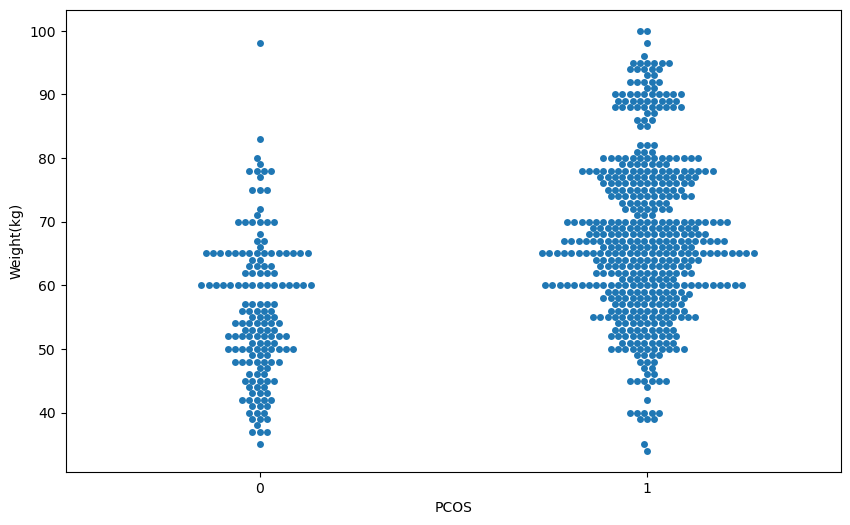

/opt/anaconda3/envs/tech_challenge_1/lib/python3.10/site-packages/seaborn/categorical.py:3399: UserWarning: 8.7% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/opt/anaconda3/envs/tech_challenge_1/lib/python3.10/site-packages/seaborn/categorical.py:3399: UserWarning: 34.3% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


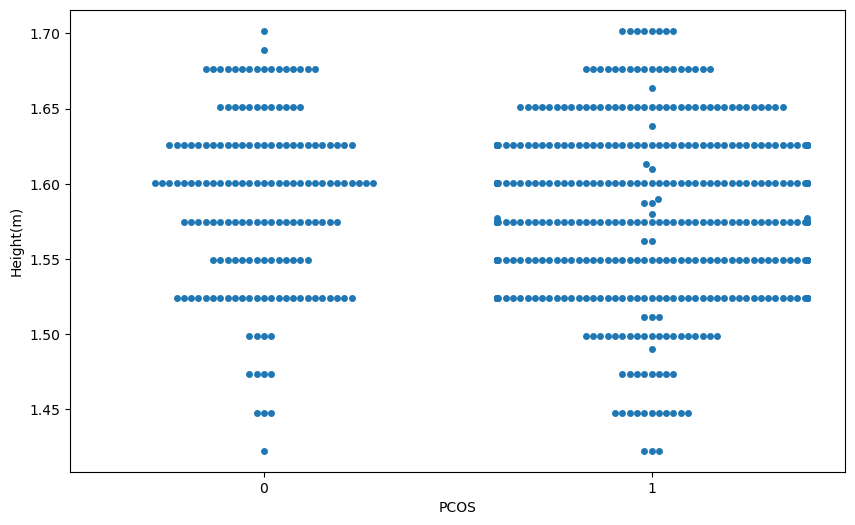

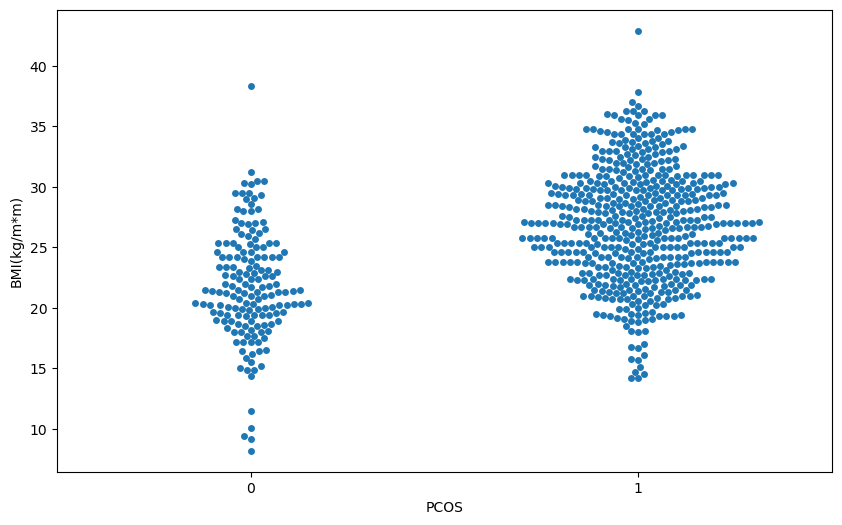

In [593]:
#Vamos entender melhor os outliers usando o gráfico de swarplot, porque ele nos mostra melhor todos os pontos da amostra, espalhando
#os pontos e evitando sobreposições.

for col in numeric_cols_names:
  fig, ax = plt.subplots(figsize=(10,6))
  sns.swarmplot(data=dataset, x='PCOS', y=col, size=5)
  plt.show()

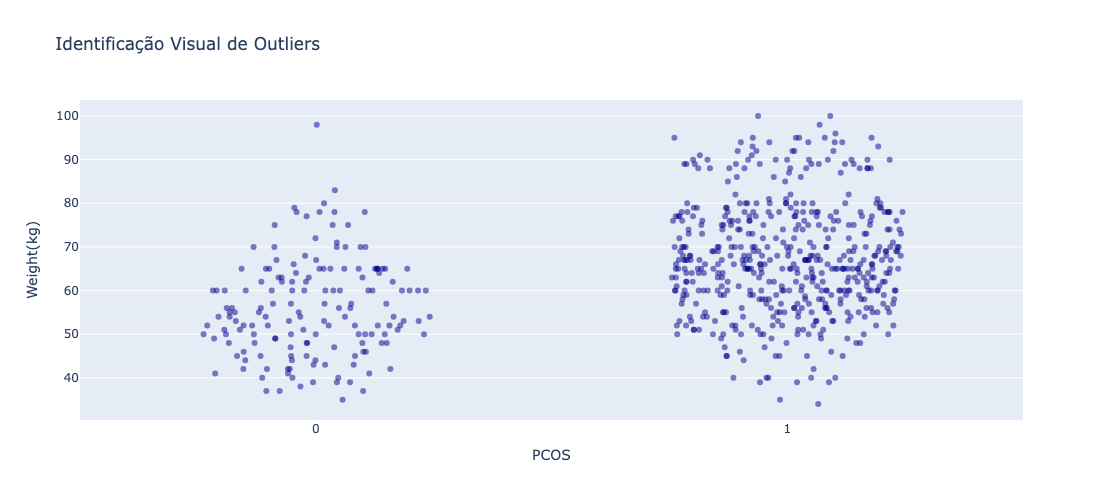

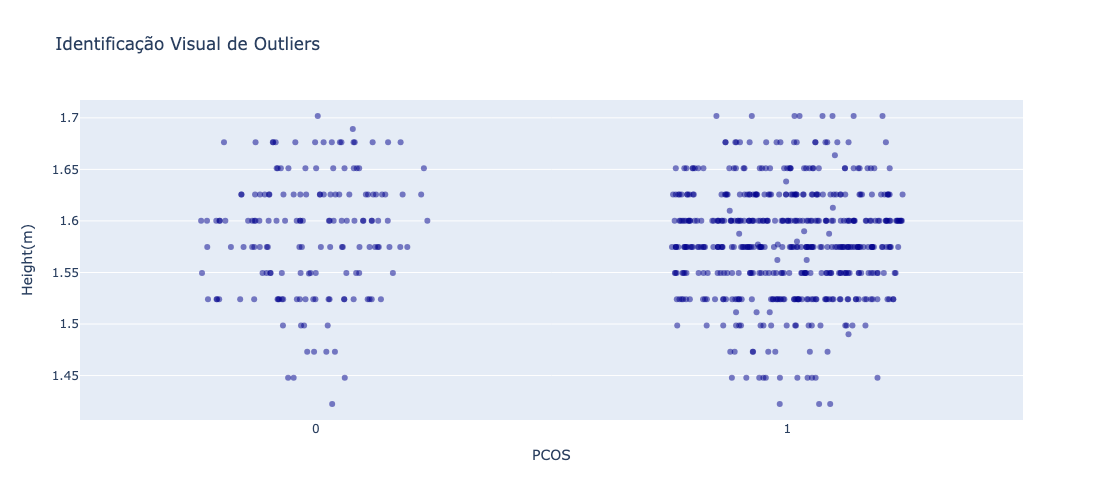

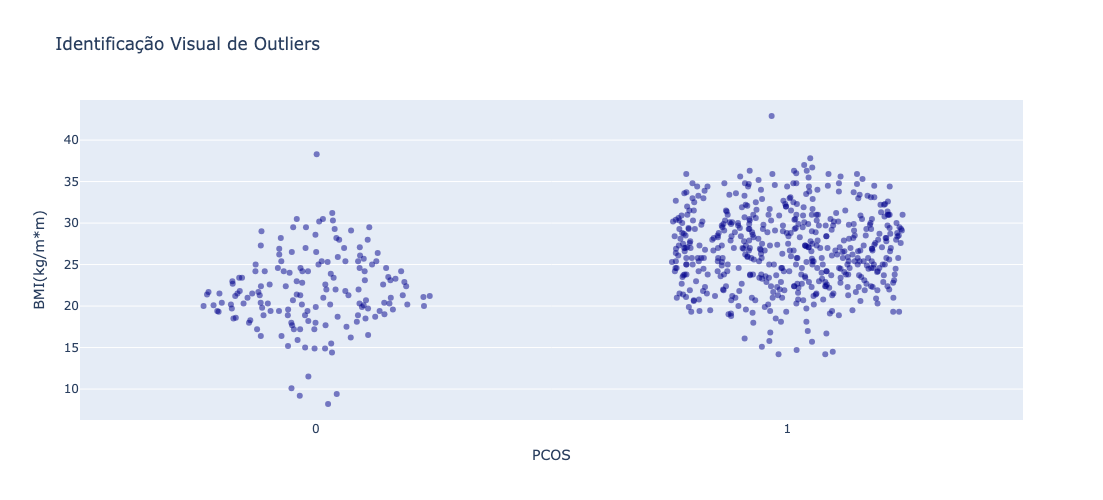

In [594]:
#Para poder identificar os outliers nos gráficos (ver o valor de fato de cada um deles), eu vou plotar novamente gráficos 
#similares ao swarmplot, mas, desta vez, usando a biblioteca plotly porque eu consigo identificar os valores pelo hover do mouse.

for col in numeric_cols_names:
    fig = px.strip(
        dataset,
        x='PCOS',
        y=col,
        hover_data=[
            col
        ], 
        stripmode='overlay', 
        height=500,
        title='Identificação Visual de Outliers',
    )

    fig.update_traces(
        jitter=1.0,
        marker=dict(
        size=6,  
        opacity=0.5, 
        color='darkblue'
    ),)

    fig.show()

In [595]:
is_outlier = (dataset['Weight(kg)'] > 100.0) | (dataset["Height(m)"] > 1.72) | (dataset["Height(m)"] < 1.40)

dataset = dataset.drop(dataset[is_outlier].index)

In [596]:
#Vamos ver quantas linhas nós eliminamos:
dataset.shape

(667, 33)

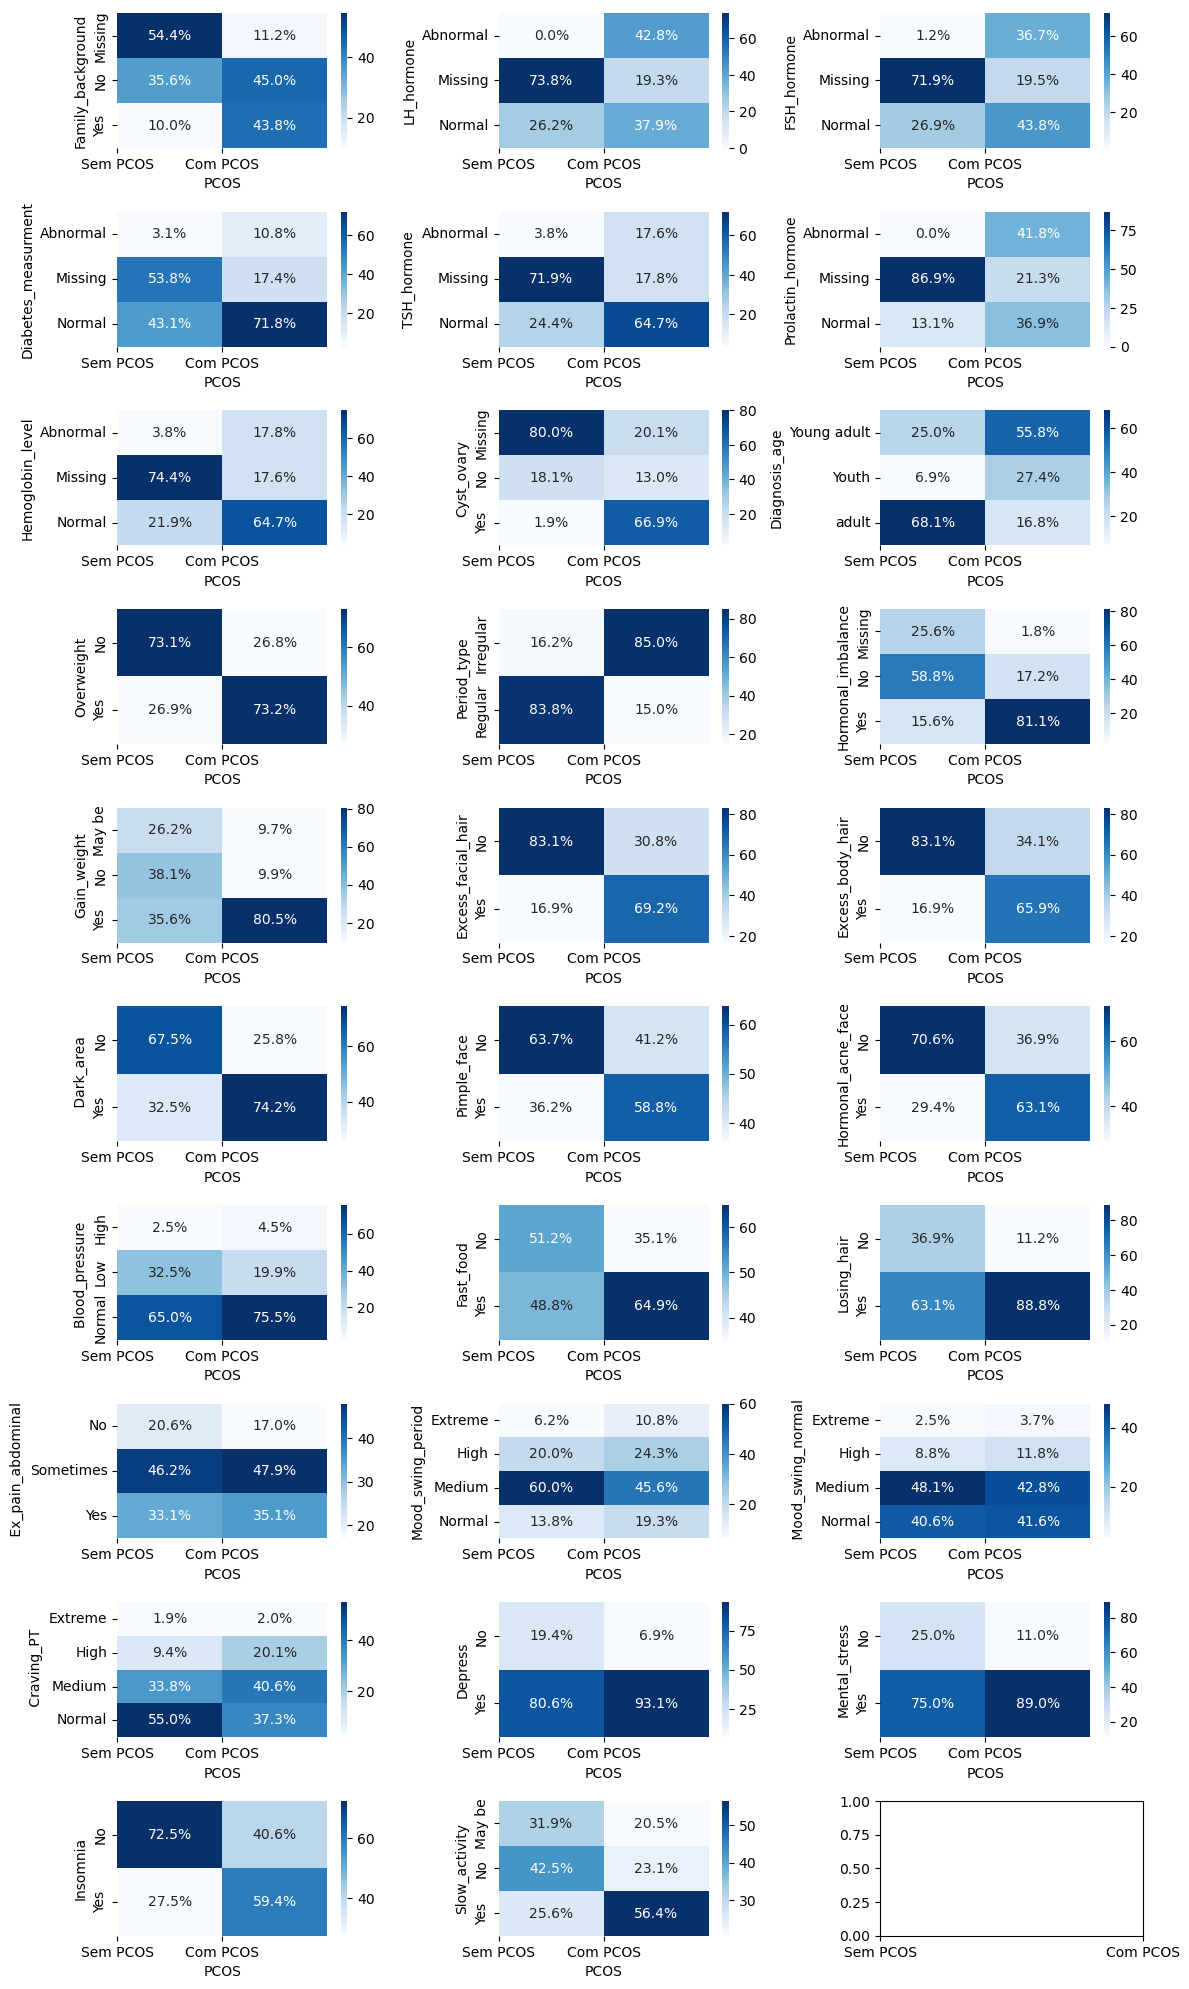

In [597]:
#Por fim, vou fazer mapas de calor com tabelas cruzando, confrontando cada variável categórica da base de dados com 
#a variável-target. Com isso, espero ter uma noção melhor de quais variáveis podem ter mais influência na variável-target.

#Primeiro, seleciono somente as variáveis categóricas do dataset:
categoric_cols = dataset.select_dtypes(exclude=['number']).columns

#Configuração de quantos gráficos por linha eu desejo ter:
fig, axes = plt.subplots(nrows=np.ceil(len(categoric_cols)/3).astype(int), ncols=3, figsize=(12, 20))

#para cada coluna categórica:
for index in range(len(categoric_cols)):
  #Crio a tabela cruzada:
  cross_table = pd.crosstab(dataset[categoric_cols[index]], dataset['PCOS'], normalize="columns")*100
    
  #Faço o mapa de calor:
  labels = cross_table.map(lambda x: f"{x:.1f}%")
  sns.heatmap(cross_table, annot=labels, fmt="", cmap='Blues', ax=axes[np.floor(index/3).astype(int), index%3])
    
  axes[np.floor(index/3).astype(int), index%3].set_xticks(ticks=[0,1], labels=['Sem PCOS', 'Com PCOS'])
  plt.xticks(ticks=[0,1], labels=['Sem PCOS', 'Com PCOS'])

plt.tight_layout()

**Insights:** pela observação dos mapas acima, podemos pesar algumas coisas:

- Entre as mulheres **sem SOP** que fizeram exames dos níveis do LH_hormone, **nenhuma** apresentou níveis anormais do hormônio, enquanto quase a metade (42,8%) das mulheres **com SOP** apresentaram anomalias neste mesmo exame. Da mesma forma, apenas 1,2% das mulheres **sem SOP** que fizeram exames de FSH_hormone tiveram níveis anormais do exame, contra mais de um terço (36,7%) das mullheres **com SOP**. De maneira geral, o percentual de mulheres sem SOP com alguma anormalidade nos exames hormonais é bem mais baixa do que o percentual das mulheres com SOP, mas é difícil tomar conclusões rígidas, porque há muita ausência de dados entre as mulheres sem SOP.

- Outro dado que chamou a atenção é o de **cisto no ovário**, presente em **dois terços (66,9%) das mulheres diagnosticadas com SOP**, mas em apenas 1,9% das mulheres sem SOP, mas novamente a comparação fica comprometida pela falta de dados muio elevada entre as mulheres sem a condição.

- Nas categorias sem o problema de ausência de dados, fica mais fácil enxergar correlações que podem ser verdadeiras. O **sobrepeso** e a **regularidade do ciclo menstrual** são duas categorias em que a diferença entre mulheres com SOP e sem SOP fica gritante. São **73,2% de mulheres com SOP** que têm sobrepeso, contra somente **26,9% das mulheres sem SOP**. Enquanto **85% das mulheres com SOP** têm ciclos menstruais irregulares, somente **16,2% das mulheres sem SOP** sofrem com o mesmo problema.

- Outras categorias em que a diferença é nítida: **ganho de peso (similar à categoria de sobrepeso), excesso de pelos faciais e corporais, áreas escurecidas, espinhas e acne hormonal, insônia e atividade mais lenta**.

### Insights da Análise Exploratória dos Dados:

- Dataset com dimensionalidade média/alta (32 colunas preditoras), sendo possível a necessidade de aplicar um PCA;
- Dataset desbalanceado, com concentração de mulheres diagnosticadas com SOP (76,2%), indicando a importância de usar o stratify a hora de separar os conjuntos de treino e teste;
- Muitos dados ausentes em 9 das 32 colunas preditoras do dataset, concentrando-se nas variáveis relativas a exames;
- A ausência desses dados costuma se repetir para as mesmas amostras;
- A distribuição dos dados numéricos nas duas classes da variável-alvo indicam que a altura da paciente não deve ter nenhuma correlação com o diagnóstico de SOP, provavelmente podendo ser desconsiderada das variáveis preditoras, enquanto mostrou que pacientes diagnosticadas com SOP têm maior peso corporal e IMC, indicando que essas podem ser variáveis bem importantes para a análise;
- Pela análise inicial das variáveis categóricas contra a variável-alvo, podemos encontrar que as seguintes variáveis parecem ter bastante relevânciapara o diagnósticos de SOP: taxas do hormônio LH, FSH, TH e prolactina, níveis de hemoglobina, presença de cistos no ovário, sobrepeso, irregularidades no ciclo menstrual, desbalanço nos níveis hormonais, ganho de peso, excesso de pelos, áreas escurecidas, espinhas, presença de acne hormonal, queda de cabelo, insônia e atividade mais lenta.

  *Observação: ainda não foi feita a matriz de correlação entre as variáveis porque é necessário primeiro converter todas as variáveis para dados numéricos, então isso será feito na próxima etapa*.

## *Próximos passos:*

- Separar a variável-alvo (y) das variáveis prditoras (X);
- Separar os conjuntos de treino e teste;
- Codificar as variáveis categóricas;
- Escalonamento das variáveis numéricas;
- Novas análises: matriz de correlação;
- Drop de colunas com pouca relevância para a análise e/ou possível redução de dimensionalidade com PCA.

## Processamento dos dados:

#### Separação da variável-alvo do restante do dataset:

In [604]:
X = dataset.drop(columns=['PCOS'])
y = dataset['PCOS'] 

#### Separação dos conjuntos de treino e teste:

In [722]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=True, stratify=y, random_state=36)

#Conferindo se as proporções estão corretas:
print(f"Tamanho da base de treino:{len(X_train)/len(dataset)*100: .2f}%")
print(f"tamanho da base de teste:{len(X_test)/len(dataset)*100: .2f}%")

Tamanho da base de treino: 79.91%
tamanho da base de teste: 20.09%


#### Codificação das variáveis categóricas:

A primeira coisa que eu vou fazer para a codificação das variáveis categóricas é separá-las em 2 grupos: as variáveis binárias (somente duas classes) e as variáveis com mais de 2 classes possíveis.

Eu decidi fazer isso porque, para as variáveis binárias, eu gostaria de usar o codificador OrdinalEncoder. Este codificador normalmente deve ser usado apenas em variáveis categóricas que são hierarquizadas entre si, porém, no caso de variáveis binárias, ele também pode ser usado, já que o resultado é apenas 0 ou 1, que o computador já costuma interpretar como true ou false, em vez de atribuir mais peso/importância às variáveis com números maiores.

Já para as variáveis com mais de duas classes,vamos primeiro analisar a quantidade de classes de cada uma delas para decidir entre o TargetEncoder e o OneHotEncoder (mais popular).

In [606]:
#Separação das colunas categóricas e numéricas:
categoric_cols_names = X_train.select_dtypes(exclude=['number']).columns
numeric_cols_names = X_train.select_dtypes(include=['number']).columns

categoric_cols = X_train[categoric_cols_names]

#Separação das colunas categóricas binárias e não-binárias:
binary_cols = categoric_cols.loc[:, categoric_cols.nunique() == 2].columns
non_binary_cols = categoric_cols.loc[:, categoric_cols.nunique() > 2].columns

#Quero ver os valores possíveis as colunas binárias para definir a orderm (0 para o que for "não" ou ausência de uma condição
#e 1 para o que for "sim" ou presença de uma condição:
for col in binary_cols:
  print(f'{col}:')
  print(set(X[col]))
  print("")

Overweight:
{'No', 'Yes'}

Period_type:
{'Regular', 'Irregular'}

Excess_facial_hair:
{'No', 'Yes'}

Excess_body_hair:
{'No', 'Yes'}

 Dark_area:
{'No', 'Yes'}

Pimple_face:
{'No', 'Yes'}

Hormonal_acne_face:
{'No', 'Yes'}

Fast_food:
{'No', 'Yes'}

Losing_hair:
{'No', 'Yes'}

Depress:
{'No', 'Yes'}

Mental_stress:
{'No', 'Yes'}

Insomnia:
{'No', 'Yes'}



In [607]:
from sklearn.preprocessing import OrdinalEncoder

X_train_encoded = X_train.copy()

#Vou explicitar a ordem das classes somente para ter certeza de que o codificador vai atribuir o 0 e o 1 de acordo com o que eu quero:
ordinal_encoder = OrdinalEncoder(categories=[['No', 'Yes']])
period_type_ordinal_encoder = OrdinalEncoder(categories=[['Regular', 'Irregular']])

for col in binary_cols:
  if col == 'Period_type':
    X_train_encoded[col] = period_type_ordinal_encoder.fit_transform(X_train_encoded[[col]])
  else:
    X_train_encoded[col] = ordinal_encoder.fit_transform(X_train_encoded[[col]])

In [609]:
#Vamos conferir como ficou:

X_train_encode[binary_cols].head()

,Overweight,Period_type,Excess_facial_hair,Excess_body_hair,Dark_area,Pimple_face,Hormonal_acne_face,Fast_food,Losing_hair,Depress,Mental_stress,Insomnia
647,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,1.0,1.0,1.0
61,1.0,1.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,1.0
472,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
585,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,1.0,0.0
484,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


In [610]:
#Agora vamos ver as variáveis categóricas não-binárias:

for col in non_binary_cols:
  print(f'{col}:')
  print(set(X[col]))
  print("")

Family_background:
{'No', 'Yes', 'Missing'}

LH_hormone:
{'Abnormal', 'Normal', 'Missing'}

FSH_hormone:
{'Abnormal', 'Normal', 'Missing'}

Diabetes_measurment:
{'Abnormal', 'Normal', 'Missing'}

TSH_hormone:
{'Abnormal', 'Normal', 'Missing'}

Prolactin_hormone:
{'Abnormal', 'Normal', 'Missing'}

Hemoglobin_level:
{'Abnormal', 'Normal', 'Missing'}

Cyst_ovary:
{'No', 'Yes', 'Missing'}

Diagnosis_age:
{'Youth', 'adult', 'Young adult'}

Hormonal_imbalance:
{'No', 'Yes', 'Missing'}

Gain_weight:
{'No', 'Yes', 'May be'}

Blood_pressure :
{'Low', 'High', 'Normal'}

 Ex_pain_abdominal:
{'No', 'Yes', 'Sometimes'}

Mood_swing_period:
{'Extreme', 'High', 'Normal', 'Medium'}

 Mood_swing_normal:
{'Medium', 'Extreme', 'High', 'Normal'}

 Craving_PT:
{'Medium', 'Extreme', 'High', 'Normal'}

Slow_activity:
{'No', 'Yes', 'May be'}



**Insights:** como vimos acima, a maioria das colunas não-binárias contém somente 3 classes, e algumas outras contêm 4. Esse número de classes é pequeno e, mesmo com um número de 17 colunas, a dimensionalidade dos dados não vai crescer tão exponencialmente que impeça o uso do OneHotEncoder, que é um codificador determinístico, que não precisa olhar para a variável-target e é muito mais usado do que o TargetEncoder.

In [612]:
from sklearn.preprocessing import OneHotEncoder

for col in non_binary_cols:
  #Usando o drop='first'também evitamos aumentar mais a dimensionalidade dos dados:
  current_one_hot_encoder = OneHotEncoder(sparse_output=False, drop='first')
  encoded_cols = current_one_hot_encoder.fit_transform(X_train_encoded[[col]])
  new_columns_names = current_one_hot_encoder.get_feature_names_out(input_features=[col])
  encoded_cols_df = pd.DataFrame(encoded_cols, columns=new_columns_names, index=X_train_encoded.index)
  X_train_encoded = pd.concat([X_train_encoded, encoded_cols_df], axis=1)
  X_train_encoded = X_train_encoded.drop(columns=[col])

In [613]:
#Aquela conferida:

print(f"O novo número de colunas é {X_train_encoded.shape[1]}")
X_train_encoded.head()

O novo número de colunas é 52


,Overweight,Period_type,Excess_facial_hair,Excess_body_hair,Dark_area,Pimple_face,Hormonal_acne_face,Fast_food,Losing_hair,Depress,Mental_stress,Insomnia,Weight(kg),Height(m),BMI(kg/m*m),Family_background_No,Family_background_Yes,LH_hormone_Missing,LH_hormone_Normal,FSH_hormone_Missing,FSH_hormone_Normal,Diabetes_measurment_Missing,Diabetes_measurment_Normal,TSH_hormone_Missing,TSH_hormone_Normal,Prolactin_hormone_Missing,Prolactin_hormone_Normal,Hemoglobin_level_Missing,Hemoglobin_level_Normal,Cyst_ovary_No,Cyst_ovary_Yes,Diagnosis_age_Youth,Diagnosis_age_adult,Hormonal_imbalance_No,Hormonal_imbalance_Yes,Gain_weight_No,Gain_weight_Yes,Blood_pressure _Low,Blood_pressure _Normal,Ex_pain_abdominal_Sometimes,Ex_pain_abdominal_Yes,Mood_swing_period_High,Mood_swing_period_Medium,Mood_swing_period_Normal,Mood_swing_normal_High,Mood_swing_normal_Medium,Mood_swing_normal_Normal,Craving_PT_High,Craving_PT_Medium,Craving_PT_Normal,Slow_activity_No,Slow_activity_Yes
670,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,1.0,1.0,1.0,0.0,74.0,1.5748,29.8,0.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0
90,1.0,1.0,0.0,1.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,0.0,76.0,1.6002,29.7,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
306,1.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,66.0,1.5748,26.6,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
642,0.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,0.0,45.0,1.5240,19.3,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
459,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,67.0,1.4732,30.9,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0


### Escalonamento das variáveis (features scaling):

Aqui, preciso pontuar que foi onde eu mais encontrei dificuldades para tomar uma decisão. Com as nossas variáveis categóricas agora codificadas em números, não parece existir um consenso sobre escalonar também essas variáveis ou não. Alguns recomendam escalonar para manter todos os dados na mesma escala numérica, enquanto outros afirmam que escalonar variáveis categóricas codificadas (principalmente as binárias) destrói a natureza discreta e intuitiva dos dados.

Usar a normalização para os meus dados (MinMaxScaler) seria uma boa opção porque colocaria as 3 colunas de dados contínuas na mesma escala dos demais dados, que estão todos no intervalo entre 0 e 1. Porém, a presença de alguns outliers extremos - principalmente nas colunas de peso (Weight(kg)) e IMC (BMI(kg/m*m)) - me preocupa...será que isso não achataria demais o intervalo dos demais dados, prejudicando a variância? 

Como há poucos outliers mais extremos, optei por removê-los do dataset (muito provavelmente os outliers de peso e IMC são as mesmas amostras) e seguir com a aplicação da normalização (MinMaxScaler) em vez da padronização (Z-score normalization). Para isso, precisei voltar lá no passado (antes da separação da variável-target do restante do dataset) e remover os outliers corretamente com todas as colunas ainda juntas.

In [614]:
#Agora, com os outliers removidos, vamos usar a normalização para escalonar as variáveis contínuas:

from sklearn.preprocessing import MinMaxScaler

min_max_scaler = MinMaxScaler()

#Aplico o escalonador MinMaxScaler e volto o formato para um DataFrame
min_max_scaled_cols = min_max_scaler.fit_transform(X_train_encoded[numeric_cols_names])
min_max_scaled_cols_df = pd.DataFrame(min_max_scaled_cols, columns = numeric_cols_names, index=X_train_encoded.index)

#Depois, removo as colunas que vão ser escalonadas porque vou concatená-las na sequência já escalonadas:
X_train_encoded_temp = X_train_encoded.drop(columns=numeric_cols_names)
X_train_encoded_and_scaled = pd.concat([X_train_encoded_temp, min_max_scaled_cols_df], axis=1)

### <u>Nova análise dos dados: matriz de correlação:</u>

Agora com os dados todos codificados e escalonados, podemos fazer a matriz de correlação:

In [615]:
correlation_matrix = X_train_encoded_and_scaled.corr()
correlation_matrix

,Overweight,Period_type,Excess_facial_hair,Excess_body_hair,Dark_area,Pimple_face,Hormonal_acne_face,Fast_food,Losing_hair,Depress,Mental_stress,Insomnia,Family_background_No,Family_background_Yes,LH_hormone_Missing,LH_hormone_Normal,FSH_hormone_Missing,FSH_hormone_Normal,Diabetes_measurment_Missing,Diabetes_measurment_Normal,TSH_hormone_Missing,TSH_hormone_Normal,Prolactin_hormone_Missing,Prolactin_hormone_Normal,Hemoglobin_level_Missing,Hemoglobin_level_Normal,Cyst_ovary_No,Cyst_ovary_Yes,Diagnosis_age_Youth,Diagnosis_age_adult,Hormonal_imbalance_No,Hormonal_imbalance_Yes,Gain_weight_No,Gain_weight_Yes,Blood_pressure _Low,Blood_pressure _Normal,Ex_pain_abdominal_Sometimes,Ex_pain_abdominal_Yes,Mood_swing_period_High,Mood_swing_period_Medium,Mood_swing_period_Normal,Mood_swing_normal_High,Mood_swing_normal_Medium,Mood_swing_normal_Normal,Craving_PT_High,Craving_PT_Medium,Craving_PT_Normal,Slow_activity_No,Slow_activity_Yes,Weight(kg),Height(m),BMI(kg/m*m)
Overweight,1.000000,0.362942,0.344978,0.255911,0.384850,0.183799,0.231453,0.291790,0.240268,0.084725,0.085746,0.280449,-0.013346,0.226370,-0.273804,-0.069853,-0.280868,-0.004528,-0.210405,0.124191,-0.259337,0.136781,-0.335751,-0.021529,-0.278486,0.156497,-0.032344,0.326948,0.008448,-0.240005,-0.230372,0.326817,-0.466318,0.524406,-0.125771,0.092220,0.110109,0.024802,-0.013188,-0.016977,0.036109,0.003197,-0.115663,0.127404,0.124770,0.088542,-0.198604,-0.184922,0.222510,0.704865,-0.008075,0.756537
Period_type,0.362942,1.000000,0.288245,0.318203,0.264874,0.197484,0.320651,0.165694,0.187949,0.088488,0.127283,0.263350,0.125870,0.217339,-0.414593,0.039455,-0.404060,0.121497,-0.340900,0.283071,-0.422804,0.304475,-0.462867,0.091716,-0.443731,0.355811,-0.029736,0.448816,0.108099,-0.410533,-0.342686,0.428932,-0.232894,0.314485,-0.063852,0.054582,0.028960,-0.014065,-0.020048,-0.033846,0.076504,0.071159,-0.060806,-0.004597,0.040251,0.114619,-0.146612,-0.191508,0.240956,0.297160,-0.118203,0.370683
Excess_facial_hair,0.344978,0.288245,1.000000,0.618881,0.342878,0.317733,0.363999,0.134426,0.266400,0.097824,0.205440,0.217662,0.056744,0.209147,-0.345412,-0.043915,-0.353442,0.032652,-0.308257,0.234152,-0.345221,0.262383,-0.376289,0.004966,-0.328878,0.283529,0.046388,0.338944,0.029926,-0.312195,-0.372623,0.450152,-0.285555,0.357528,-0.090594,0.082627,0.105091,-0.047396,0.015040,-0.031488,0.025345,-0.004281,-0.015525,0.016115,0.143064,0.105825,-0.218451,-0.161396,0.239444,0.311618,-0.066093,0.366586
Excess_body_hair,0.255911,0.318203,0.618881,1.000000,0.326891,0.314923,0.372718,0.167856,0.252256,0.111616,0.175418,0.250004,0.070917,0.151500,-0.301294,-0.070490,-0.309711,0.007412,-0.245163,0.209083,-0.287014,0.278607,-0.341366,-0.059540,-0.286227,0.262854,-0.008180,0.355324,0.067601,-0.263238,-0.335022,0.395932,-0.200989,0.315332,-0.096076,0.080575,0.088830,0.012765,0.038502,-0.097508,0.047843,-0.025247,0.025329,-0.023710,0.086231,0.078271,-0.157347,-0.239548,0.275963,0.196643,-0.087592,0.251235
Dark_area,0.384850,0.264874,0.342878,0.326891,1.000000,0.333409,0.347945,0.205353,0.212301,0.141046,0.139921,0.315510,0.018351,0.169492,-0.310116,0.018586,-0.308583,0.052272,-0.215736,0.153636,-0.294067,0.205078,-0.311864,-0.003293,-0.271698,0.208646,0.057361,0.276244,0.059463,-0.239596,-0.226525,0.306480,-0.296638,0.367133,-0.012381,-0.010098,0.012058,0.090026,-0.004011,-0.094271,0.035849,0.047380,-0.048327,0.017923,0.114932,0.147929,-0.248435,-0.208604,0.274673,0.351624,0.013397,0.370784
Pimple_face,0.183799,0.197484,0.317733,0.314923,0.333409,1.000000,0.601342,0.180116,0.221711,0.142039,0.122504,0.272257,0.013667,0.168214,-0.277251,0.001273,-0.277719,0.064310,-0.256267,0.230572,-0.271678,0.250217,-0.300175,-0.068322,-0.286824,0.272579,0.001302,0.302309,0.061315,-0.264618,-0.227673,0.275984,-0.170550,0.226641,-0.155474,0.142662,0.087400,0.060718,-0.018238,-0.007898,0.077955,-0.040470,-0.037915,0.071496,0.126116,0.111776,-0.191874,-0.158502,0.252067,0.211536,0.023927,0.232341
Hormonal_acne_face,0.231453,0

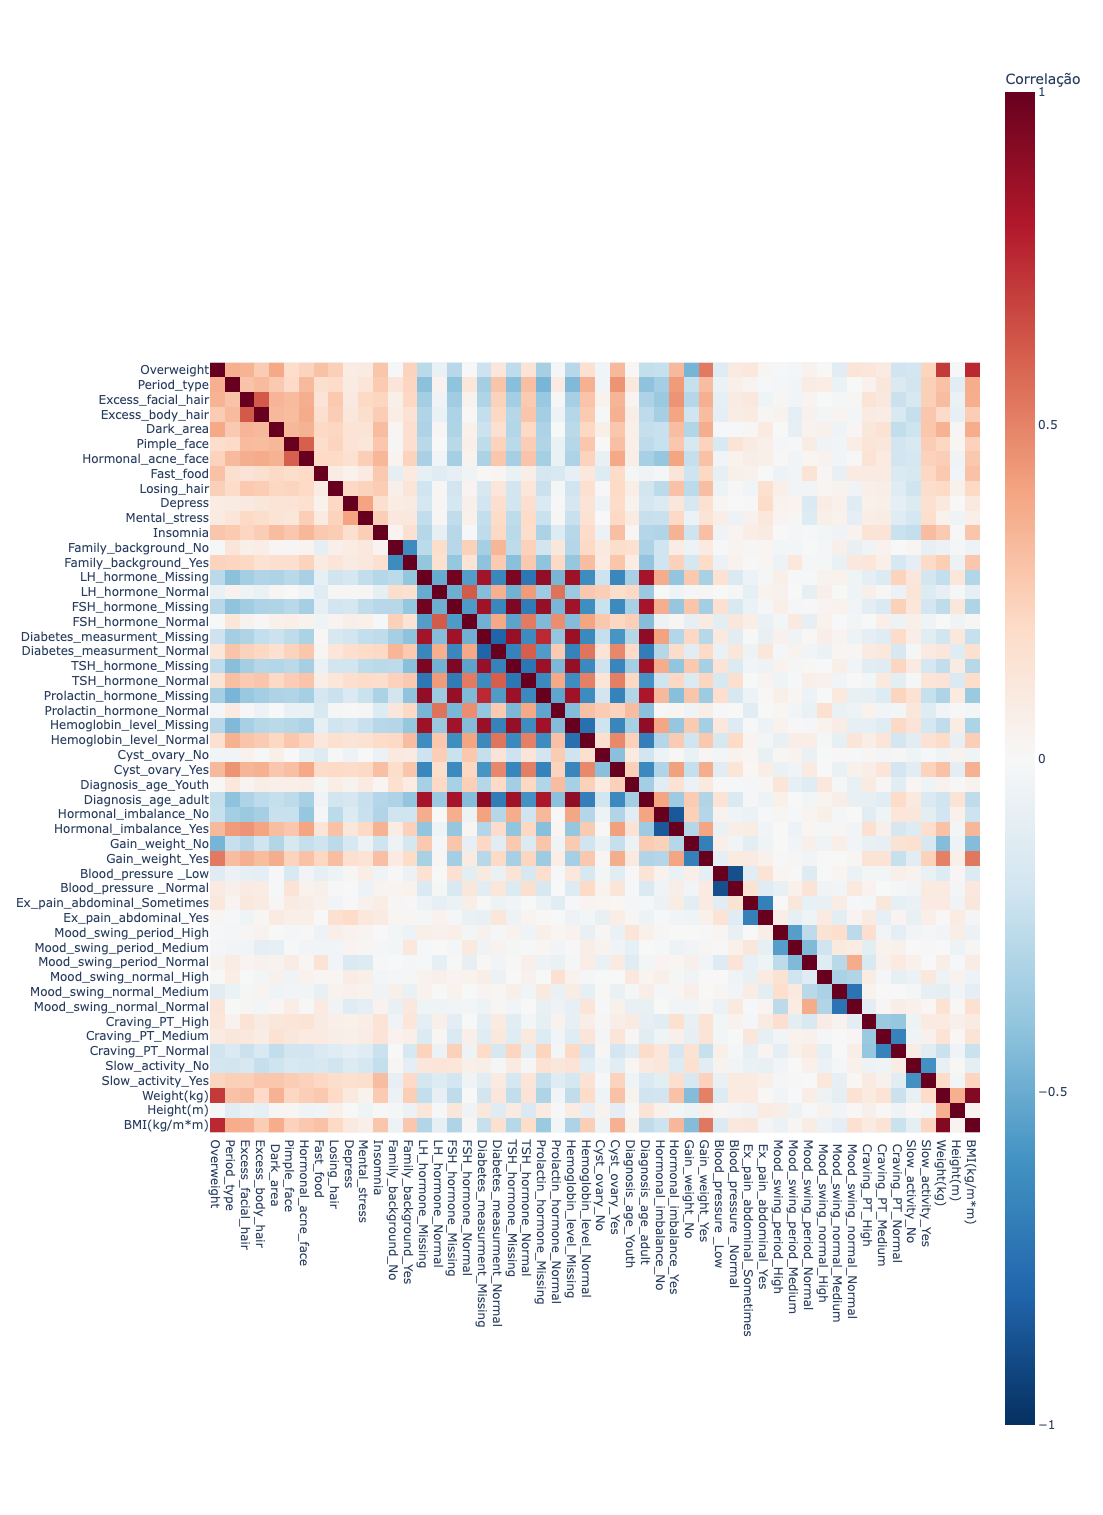

In [616]:
#Vou usar a biblioteca plotly.express para fazer uma espécie de mapa de calor da matriz de correlação porque eu
#quero ver os números apenas no hover (como os quadradinhos ficam muito pequenos, se eu usasse o heatmap do seaborn, com annot=True
#os valores acabariam se sobrepondo uns aos outros):

fig = px.imshow(
    correlation_matrix,
    labels=dict(color="Correlação"),
    color_continuous_scale='RdBu_r',  
    width=1500,
    height=1500,
    zmin=-1, zmax=1                  
)
fig.show()

In [617]:
correlation_with_y = X_train_encoded_and_scaled.corrwith(y).to_frame(y.name)
correlation_with_y

,PCOS
Overweight,0.435138
Period_type,0.626851
Excess_facial_hair,0.425924
Excess_body_hair,0.391334
Dark_area,0.384698
Pimple_face,0.202274
Hormonal_acne_face,0.281337
Fast_food,0.146645
Losing_hair,0.309352
Depress,0.140800


É muito complicado fazer a correlação entre variáveis categóricas "binarizadas"/codificadas. Existem muitos vieses/distorções, e a análise da correlação entre elas não fica assertiva. Apesar de haver formas outras de analisar correlação entre variáveis binárias, como o V de Cramér, como não estudamos isso neste módulo da pós e se trata de algo mais complexo, não me senti confortável em aplicá-lo sozinha. Por esse motivo, optei por não remover do dataframe nenhuma coluna com base na análise da correlação com a variável-alvo, porque esses valores de correlação podem estar muito fora do que seria a correlação de fato entre elas.

Desse modo, vou seguir com a redução da dimensionalidade, aplicando o algoritmo e PCA, visando a um espaço multidimensional menor para melhor aplicar o KNN para treinamento do modelo.

### Redução de dimensionalidade com PCA:

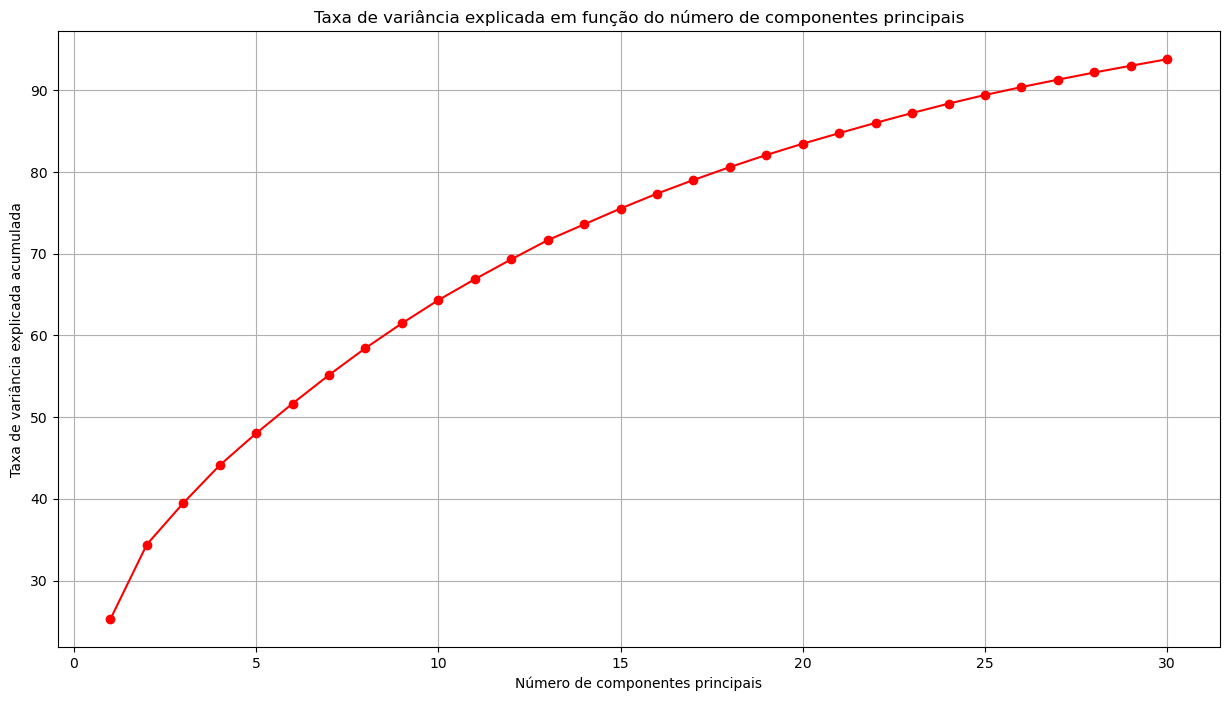

In [618]:
#Para aplicar o PCA, é preciso definir um número de componentes principais desejado.
#Para poder decidir qual o melhor número de componentes principais, primeiro plotei um gráfico com a taxa de variância acumulada 
#para ver a partir de qual ponto a curva passa a não subir mais tanto e enxergar o ponto que atinja uma taxa de variância acumulada 
#cerca de 90%.

from sklearn.decomposition import PCA

#Vou testar de 1 a 30 componentes principais, já que meu número total de colunas é 52.
n_components_range = range(1,31)
results = []
cumulative_results = []

for n in n_components_range:
  pca = PCA(n_components = n, random_state=23)
  pca.fit(X_train_encoded_and_scaled)
  results = pca.explained_variance_ratio_*100
  cumulative_results.append(np.sum(pca.explained_variance_ratio_)*100)

plt.figure(figsize=(15, 8))
plt.plot(n_components_range, cumulative_results, marker="o", linestyle="-", color="r")
plt.xlabel("Número de componentes principais")
plt.ylabel("Taxa de variância explicada acumulada")
plt.title("Taxa de variância explicada em função do número de componentes principais")
plt.grid(True)
plt.show()

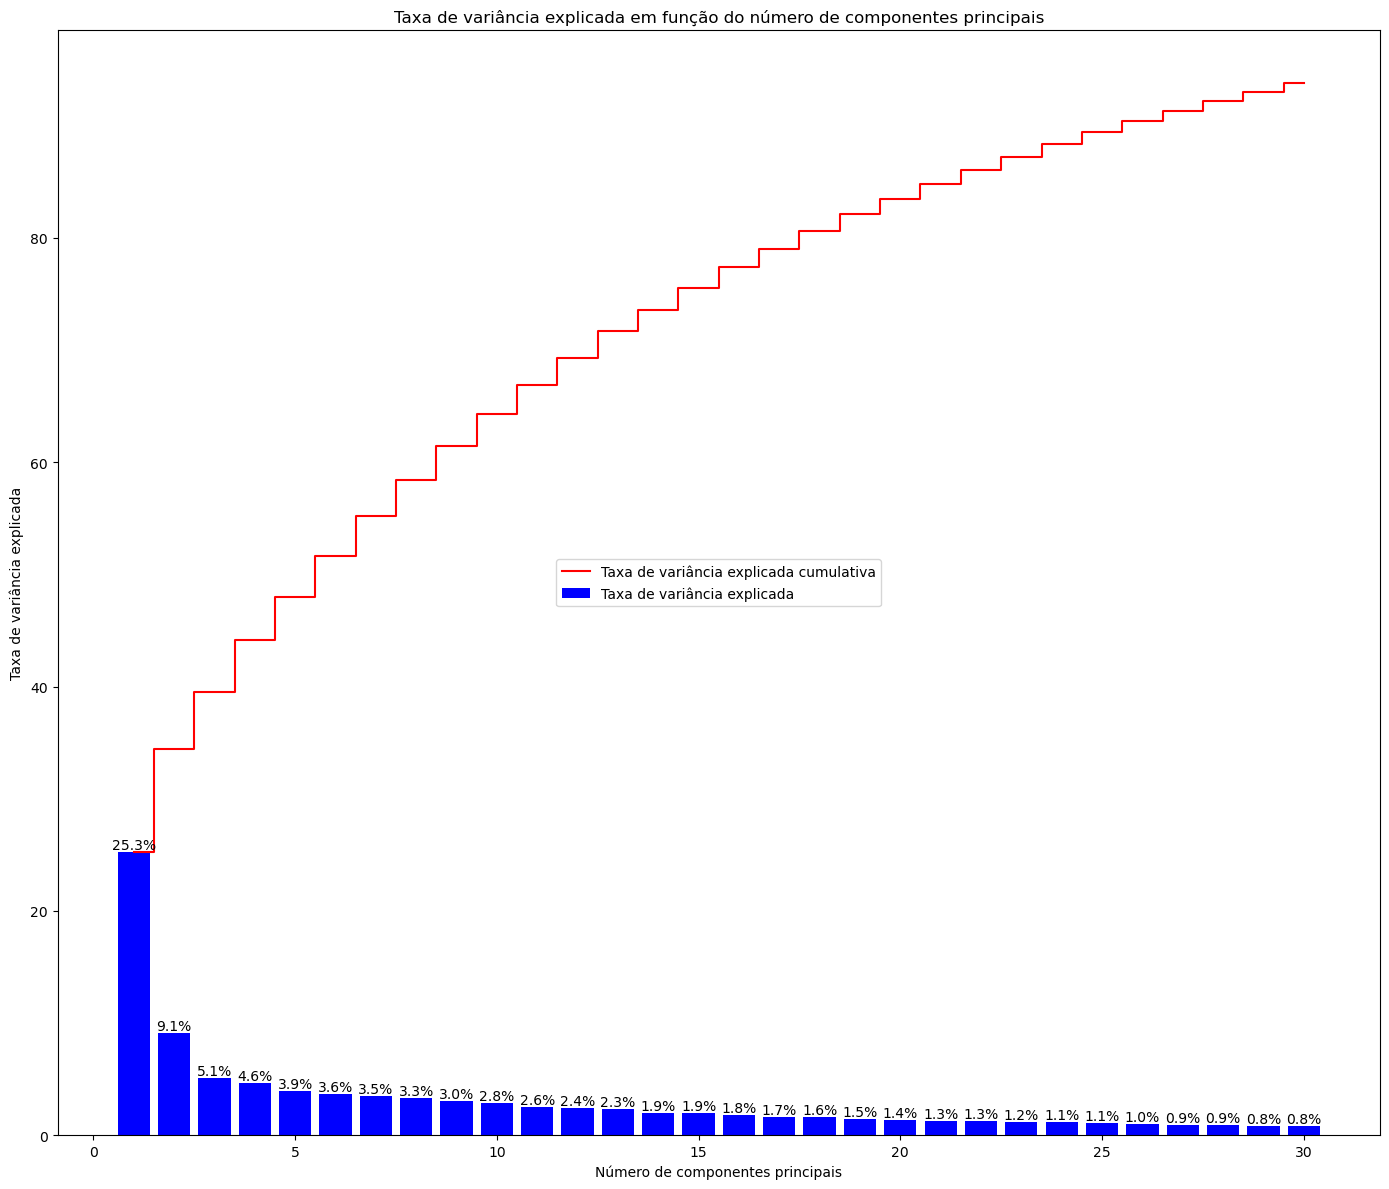

In [619]:
#Eu quis ver também os dados neste gráfico de barras porque ele nos mostra a taxa de variância de cada componente. 
#De acordo com a regra de Kaiser, todos os componentes que têm uma contribuição superior a 1% deveriam ser levados em conta. 
#Por esse motivo, quis ver de forma mais clara a contribuição individual de cada componente para ter uma ideia melhor
#do número de componentes principais que eu vou escolher.

plt.figure(figsize=(14,12))
bars = plt.bar(
    n_components_range,
    results,
    label="Taxa de variância explicada",
    color="b",
    align="center"
)

plt.step(
    n_components_range,
    cumulative_results,
    where="mid",
    color="r",
    label="Taxa de variância explicada cumulativa"
) 

plt.bar_label(bars,fmt='%.1f%%')
plt.xlabel("Número de componentes principais")
plt.ylabel("Taxa de variância explicada")
plt.title("Taxa de variância explicada em função do número de componentes principais")
plt.legend(loc="center")

plt.tight_layout()
plt.show()

**Insights:** Pelo gráfico acima, vemos que o primeiro componente sozinho já é capaz de captar 25% da variância total. O segundo ainda se destaca em relação aos demais, e depois as taxas já caem para abaixo dos 5%. Mas este gráfico me confirmou a ideia que eu já tinha ao analisar o gráfico anterior: no gráfico anterior, reparei que 25 componentes já cobriam praticamente 90% da variância total. Neste gráfico, vimos que o 26º componente é o último a ter taxa de variância acima de 1%, então acredito que 25 componentes principais seja um bom número.

In [620]:
pca = PCA(n_components=25, random_state=23)
X_train_processed = pca.fit_transform(X_train_encoded_and_scaled)
X_train_processed = pd.DataFrame(X_train_processed, columns=[f'PC{i+1}' for i in range(25)])
X_train_processed.head(10)

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12,PC13,PC14,PC15,PC16,PC17,PC18,PC19,PC20,PC21,PC22,PC23,PC24,PC25
0,0.340938,-0.221645,0.387203,-0.878707,-0.254045,0.214780,-0.668560,-0.762380,-0.588082,1.199654,-0.246370,-0.571872,-0.978597,1.189778,0.588419,-0.216124,-0.498414,-1.155940,0.211513,-0.251438,-0.131167,-0.392958,0.263160,0.064718,0.195408
1,-1.489657,0.275142,-0.353591,0.132265,-0.803308,-0.064970,-1.523607,-0.195481,0.103207,-0.552464,-1.165928,-0.420148,-0.510269,-0.339537,-0.041897,-0.384152,-0.332020,0.328993,0.886092,0.133378,-0.258287,0.183708,0.320707,0.129884,0.168262
2,-0.742266,1.488076,-0.278688,0.958243,0.221296,-0.472469,-0.155477,-0.108943,1.071266,-0.022338,-0.813343,0.377575,0.570197,0.237926,-0.386733,-0.376324,-0.517962,0.445685,0.253532,0.523254,-0.058600,0.223423,-0.407452,0.418907,-0.065090
3,0.496917,0.413723,0.352787,0.952126,0.290124,0.607398,0.774225,0.237507,-0.262490,-0.036971,-1.078064,-0.279994,-0.352394,-0.042313,-0.081107,0.535613,0.385324,-0.096215,0.046545,-0.737119,-0.175658,-1.091673,0.339124,0.333737,-0.239161
4,-1.662625,-1.261271,-0.168186,0.999695,-0.533637,-0.400549,0.303431,0.429324,-0.364208,0.182149,0.504157,0.087149,0.297389,0.112647,-0.121955,-0.122021,-0.024056,0.005957,0.018671,0.195579,-0.170113,0.049244,0.038957,-0.022941,-0.107256
5,-0.259732,2.113215,0.814096,-0.417345,0.389876,-0.662884,0.192597,0.958001,0.474963,-0.067893,-1.154997,-0.697794,-0.170559,-0.062910,-0.336534,-0.210852,-0.359299,-0.197024,0.037178,-0.574413,0.161918,0.134322,-0.240092,-0.107570,-0.454529
6,-1.214337,-0.305364,-0.127385,0.037008,0.797746,0.462674,-0.698197,-0.193729,-0.007240,-0.529414,-0.606064,-0.241462,-0.145014,0.001533,0.824244,-1.069324,0.149876,-0.094173,-0.794513,-0.222647,-0.396441,-0.806247,-0.556545,-0.364594,-0.138314
7,-1.183617,0.825683,1.315523,-0.574231,-0.501673,-0.877328,-0.178059,0.092409,0.614329,0.399931,0.076518,0.194013,0.025556,-0.632970,-0.214248,0.005675,-0.559452,0.311518,0.289684,-0.406300,0.332159,-0.496078,0.467197,-0.636123,-0.798677
8,-0.753502,1.200270,-0.031106,-1.111711,-0.846545,-0.779925,0.418776,-0.727042,-0.175829,-0.127215,-0.383870,0.693680,-0.873140,-0.868691,-0.573731,0.542030,0.144062,-0.601125,0.566613,0.805823,-0.181752,0.049532,-1.092923,0.085686,0.538529
9,-1.252970,-0.425612,-0.333978,-1.068456,-0.683787,-0.078951,-1.431526,-0.199312,-0.080009,0.199722,-0.050354,-0.429657,-0.299804,-0.607261,1.301444,0.154339,-0.580617,-0.668485,0.197678,-0.457235,0.008208,0.079830,-0.442693,0.200092,-0.186499


## Treinamento e teste dos algoritmos:

Para seguir o solicitado pelo tech challenge, eu vou treinar 3 algoritmos de classificação diferentes e depois testá-los para medirmos seus desempenhos usando as métricas principais para algoritmos classificadores.

No entanto, na sequência, eu vou criar um pipeline com todo o processamento que eu fiz nos dados para aplicar a validação cruzada usando o GridSearchCV, que eu acredito que seja a melhor opção no caso do meu dataset, que tem poucas amostras, pois a validação cruzada permite que todos os dados possam ser usados tanto para treino quanto para teste em algum dos folds criados. Além disso, o GridSearchCV nos permite testar vários hiperparâmetros de uma vez e já calcula as métricas que nós escolhermos para definir qual o melhor algoritmo para o nossos objetivo.

Os algoritmos que eu escolhi usar são o K-nearest-neighbors (KNN), o SVC e o RandomForestClassifier.

In [641]:
from sklearn.pipeline import Pipeline

#Vamos começar separando as colunas em grupos:

cat_columns = dataset.select_dtypes(exclude=['number']).drop('Period_type', axis=1)
binary_columns = ['Period_type'] + cat_columns.columns[cat_columns.nunique() == 2].tolist()
categorical_columns = cat_columns.columns[cat_columns.nunique() > 2].tolist()
numerical_columns = dataset.select_dtypes(include=['number']).drop('PCOS', axis=1).columns.tolist()   

#Cada tipo de coluna tem seu próprio "subpipeline":

ordinal_encoder_categories = [['Regular', 'Irregular']] + [['No', 'Yes']] * (len(binary_columns)-1)
binary_cols_transformer = Pipeline(steps= [('encoder', OrdinalEncoder(categories=ordinal_encoder_categories))])

#special_binary_col_transformer = Pipeline(steps= [('encoder', OrdinalEncoder(categories=[['Regular', 'Irregular']]))])

categorical_cols_transformer = Pipeline(steps=[
    ('encoder', OneHotEncoder(sparse_output=False, drop='first'))
])

numerical_cols_transformer = Pipeline(steps=[
    ('scaler', MinMaxScaler())
])                                                   

In [642]:
#Agora vamos criar o nosso preprocessador com o ColumnTransformer:

from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(
    transformers = [
        ('bin', binary_cols_transformer, binary_columns),
        ('special_bin', special_binary_col_transformer, special_binary_column),
        ('cat', categorical_cols_transformer, categorical_columns),
        ('num', numerical_cols_transformer, numerical_columns)
    ],
    remainder = 'passthrough'
)

In [685]:
#Vou completar o pipeline com a etapa do PCA, mas não vou aplicar esta etapa para o algoritmo SVC, que pode funcionar 
#melhor com um espaço multidimensional maior.

full_pipeline = Pipeline(steps= [
    ('preprocessor', preprocessor),
    ('pca', PCA(n_components=25, random_state=23))
])

In [679]:
#O KNN é um algoritmo baseado em distância, que exige a escolha de um k como o número de vizinhos mais próximos no 
#espeço multidimensional que ele deve avaliar para decidir a qual classe pertence cada novo dado. Para escolher o melhor k,
#vamos testar alguns valores e ver qual deles nos dá a menor taxa de erro:

from sklearn.neighbors import KNeighborsClassifier

knn_error = []
X_train_processed_knn = full_pipeline.fit_transform(X_train)
X_test_processed_knn = full_pipeline.transform(X_test)

#Vamos testar todos os ks ímpares de 1 a 10 (fiz a opção pelos números ímpares porque minha variável-target é binária e um número
#k par pode acabar em empate:
for i in range(1, 11, 2):
    knn = KNeighborsClassifier(n_neighbors=i)
    knn.fit(X_train_processed_knn, y_train)
    predicts = knn.predict(X_test_processed_knn)
    knn_error.append(np.mean(predicts != y_test))


Text(0, 0.5, 'Média de erro')

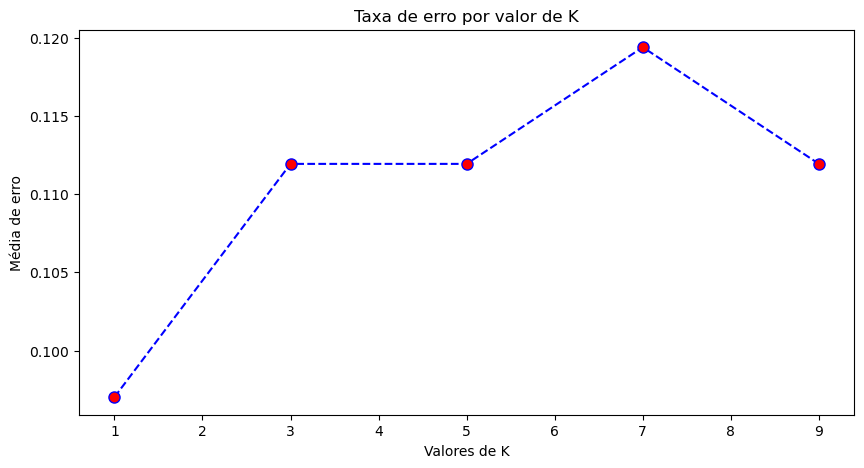

In [680]:
#Plotando os resultados graficamente para facilitar a visualização:
plt.figure(figsize=(10, 5))
plt.plot(range(1, 11, 2), knn_error, color='blue', linestyle='dashed', marker='o',
         markerfacecolor='red', markersize=8)
plt.title('Taxa de erro por valor de K')
plt.xlabel('Valores de K')
plt.ylabel('Média de erro')

**Insights:** pelo gráfico acima plotado, podemos ver que os n de 3, 5 e 9 têm taxas de erro muito parecidas, mas o 5 parece ter uma taxa levemente mais baixa, de puco mais de 11%. Ignoramos o n = 1 porque um n tão baixo fica muito sensível a ruídos e outliers da base, podendo também levar ao overfitting.

In [683]:
#Treinamento e teste do KNN usando o n escolhido de 5:

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_processed_knn, y_train)
y_knn_predictions = knn.predict(X_test_processed_knn)

O próximo algoritmo que eu quero testar é o Support Vector Machine para problemas de classficação (o SVC). Mas, como mencionei anteriormente, para usar o SVC, eu não quero submeter meu dataset ao processo de redução de dimensionalidade porque esse tipo de algoritmo se beneficia de um espaço multidimensional um pouco maior, já que ele consegue separar melhor os pontos no espaço.

In [693]:
from sklearn.svm import SVC

X_train_processed_svc = preprocessor.fit_transform(X_train)
X_test_processed_svc = preprocessor.transform(X_test)

#Eu quero testar diferentes kernel para ver qual deles vai ter uma melhor performance:
svc_error = []
kernel_opts = ['linear', 'poly', 'rbf', 'sigmoid']

for kernel in kernel_opts:
    svc = SVC(kernel=kernel, class_weight='balanced', random_state= 10)
    svc.fit(X_train_processed_svc, y_train)
    predicts = svc.predict(X_test_processed_svc)
    svc_error.append(np.mean(predicts != y_test))

Text(0, 0.5, 'Média de erro')

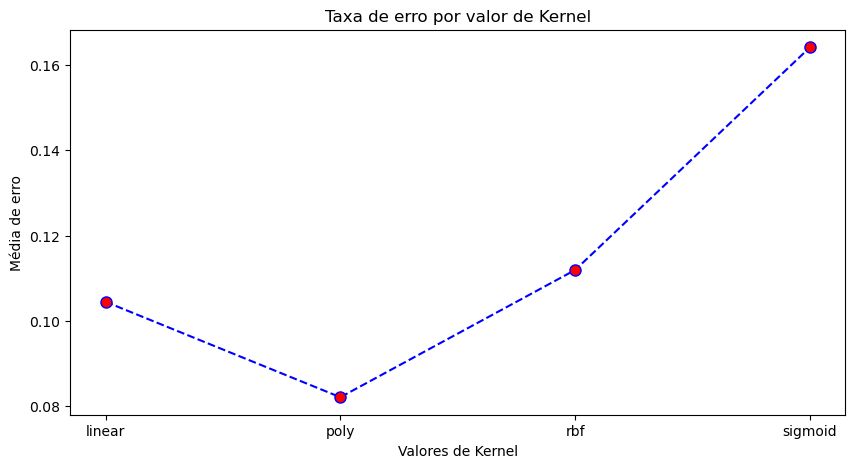

In [694]:
#Plotando os resultados graficamente para facilitar a visualização:
plt.figure(figsize=(10, 5))
plt.plot(kernel_opts, svc_error, color='blue', linestyle='dashed', marker='o',
         markerfacecolor='red', markersize=8)
plt.title('Taxa de erro por valor de Kernel')
plt.xlabel('Valores de Kernel')
plt.ylabel('Média de erro')

In [690]:
#Vamos escolher o kernel 'poly', pois teve a melhor taxa de erro, abaixo de 10%:

svc = SVC(class_weight='balanced', kernel='poly', random_state=10)
svc.fit(X_train_processed_svc, y_train)
y_svc_predictions = svc.predict(X_test_processed_svc)

Por fim, vamos testar um algoritmo de árvore de decisão. Vamos usar um ensemble, o RandomForestClassifier, para ter múltiplas árvores e, assim, poder chegar num resultado mais assertivo. O tamanho menor do nosso dataset nos permite rodar um conjunto de árvores sem muito problema.

Como esse algoritmo pode receber muitos hiperparâmetros, neste primeiro treino/teste, eu vou somente definir um critério (que vou testar) e uma profundidade máxima, e deixar os demais hiperparâmetros no automático.

In [692]:
from sklearn.ensemble import RandomForestClassifier

X_train_processed_rfc = full_pipeline.fit_transform(X_train)
X_test_processed_rfc = full_pipeline.transform(X_test)

#Vamos testar os critérios de Gini e de Entropia:
rfc_error = []
criterions = [ 'gini', 'entropy']
              
for criterion in criterions:
    rfc = RandomForestClassifier(criterion=criterion, max_depth=200, class_weight= 'balanced_subsample', random_state=42)
    rfc.fit(X_train_processed_rfc, y_train)
    predicts = rfc.predict(X_test_processed_rfc)
    rfc_error.append(np.mean(predicts != y_test))

Text(0, 0.5, 'Média de erro')

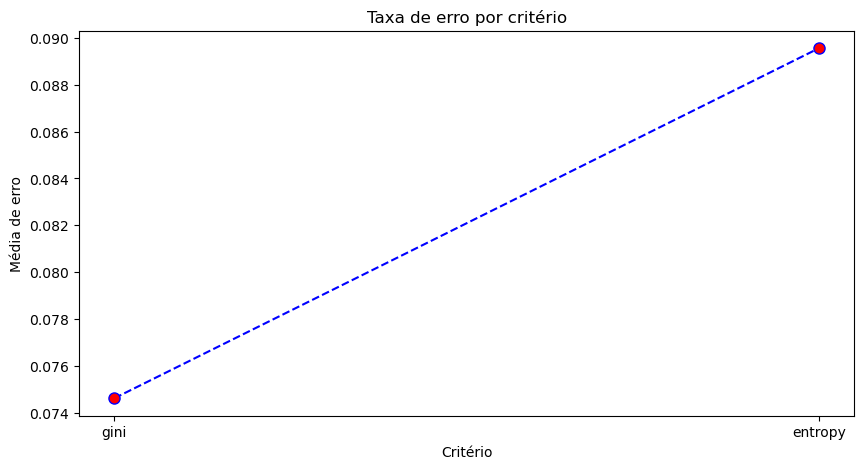

In [696]:
#Plotando os resultados graficamente para facilitar a visualização:
plt.figure(figsize=(10, 5))
plt.plot(criterions, rfc_error, color='blue', linestyle='dashed', marker='o',
         markerfacecolor='red', markersize=8)
plt.title('Taxa de erro por critério')
plt.xlabel('Critério')
plt.ylabel('Média de erro')

In [697]:
#Como o índice de Gini deu a menor taxa de erro, vamos seguir com esse critério:

rfc = RandomForestClassifier(criterion='gini', max_depth=200, class_weight= 'balanced_subsample', random_state=42)
rfc.fit(X_train_processed_rfc, y_train)
y_rfc_predictions = rfc.predict(X_test_processed_rfc)

## Avaliação dos modelos:

In [716]:
from sklearn.metrics import classification_report

predictions = {'knn': y_knn_predictions, 'svc': y_svc_predictions, 'rfc': y_rfc_predictions}
classification_reports = {}

for key in predictions.keys():
    classification_reports[key] = classification_report(y_test, predictions.get(key), labels=[0,1], target_names=['Sem SOP', 'Com SOP'])

for key in classification_reports.keys():
    print(key.upper())
    print(classification_reports.get(key))
    print('==============================') 
    print('')

KNN
              precision    recall  f1-score   support

     Sem SOP       0.74      0.81      0.78        32
     Com SOP       0.94      0.91      0.93       102

    accuracy                           0.89       134
   macro avg       0.84      0.86      0.85       134
weighted avg       0.89      0.89      0.89       134


SVC
              precision    recall  f1-score   support

     Sem SOP       0.78      0.91      0.84        32
     Com SOP       0.97      0.92      0.94       102

    accuracy                           0.92       134
   macro avg       0.88      0.91      0.89       134
weighted avg       0.92      0.92      0.92       134


RFC
              precision    recall  f1-score   support

     Sem SOP       0.87      0.81      0.84        32
     Com SOP       0.94      0.96      0.95       102

    accuracy                           0.93       134
   macro avg       0.90      0.89      0.90       134
weighted avg       0.92      0.93      0.92       134


